<a href="https://colab.research.google.com/github/Ratnor/Socio-phenotype-classifier/blob/add-neighbourhood-profile-scaling-pipeline/Final_Cleaned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Global imports and Raw data imports**

In [297]:
try:
    import hdbscan
    print("hdbscan is already installed.")
except ImportError:
    print("hdbscan not found, installing...")
    !pip install hdbscan --quiet
    import hdbscan
    print("hdbscan installed.")

hdbscan is already installed.


In [298]:
#imports
from google.colab import files
from datetime import datetime
import pandas as pd
import io
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import variation
from scipy.fft import fft, fftfreq
import re
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics  import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score, calinski_harabasz_score, davies_bouldin_score
import joblib

In [299]:
#Load the crime dataset into dataframe
crimeFile = 'Major_Crime_Indicators_Open_Data_-3805566126367379926.csv'
df_mci_raw = pd.read_csv(crimeFile)
df_mci_raw.shape

(430614, 31)

In [300]:
#Load the neighbourhood dataset into dataframe
neighbourhoodFile = 'neighbourhood-profiles-2021-158-model(1).xlsx'
df_neighbourhood_profiles = pd.read_excel(neighbourhoodFile)

# We want to tranpose the table such that the first column values become the header
df_neighbourhood_profiles = df_neighbourhood_profiles.transpose()

# Set the first row as the new header
new_header = df_neighbourhood_profiles.iloc[0]
df_neighbourhood_profiles = df_neighbourhood_profiles[1:]
df_neighbourhood_profiles.columns = new_header

# ─── A) Clean up column names ───
df_neighbourhood_profiles.columns = (
    df_neighbourhood_profiles.columns
        .str.strip()                                # remove leading/trailing spaces
        .str.replace(r'\s+', ' ', regex=True)       # collapse multiple spaces
)

#Rename columns with duplicate names
cols=pd.Series(df_neighbourhood_profiles.columns)
for dup in df_neighbourhood_profiles.columns[df_neighbourhood_profiles.columns.duplicated(keep=False)]:
    cols[df_neighbourhood_profiles.columns.get_loc(dup)] = ([dup + '.' + str(d_idx)
                                     if d_idx != 0
                                     else dup
                                     for d_idx in range(df_neighbourhood_profiles.columns.get_loc(dup).sum())]
                                    )
df_neighbourhood_profiles.columns=cols


# Display the first few rows with the correct headers
display(df_neighbourhood_profiles.head())

Neighbourhood Name,Neighbourhood Number,TSNS 2020 Designation,Total - Age groups of the population - 25% sample data,0 to 14 years,0 to 4 years,5 to 9 years,10 to 14 years,15 to 64 years,15 to 19 years,20 to 24 years,...,Between 9 a.m. and 11:59 a.m.,Between 12 p.m. and 4:59 a.m.,Total - Eligibility for instruction in the minority official language for the population in private households born in 2003 or later - 25% sample data,Children eligible for instruction in the minority official language,Children not eligible for instruction in the minority official language,"Total - Eligibility and instruction in the minority official language, for the population in private households born between 2003 and 2015 (inclusive) - 25% sample data",Children eligible for instruction in the minority official language.1,Eligible children who have been instructed in the minority official language at the primary or secondary level in Canada,Eligible children who have not been instructed in the minority official language at the primary or secondary level in Canada,Children not eligible for instruction in the minority official language.1
West Humber-Clairville,1,Not an NIA or Emerging Neighbourhood,33300,4295,1460,1345,1485,23640,1860,3175,...,1665,2935,5430,410,5020,3875,335,255,75,3540
Mount Olive-Silverstone-Jamestown,2,Neighbourhood Improvement Area,31345,5690,1650,1860,2175,21490,2280,2675,...,1145,2965,7285,510,6780,5540,395,245,145,5145
Thistletown-Beaumond Heights,3,Neighbourhood Improvement Area,9850,1495,505,540,455,6615,570,745,...,395,635,1860,180,1685,1325,120,75,45,1205
Rexdale-Kipling,4,Not an NIA or Emerging Neighbourhood,10375,1575,505,615,455,6950,515,715,...,425,775,1910,135,1770,1370,90,75,25,1275
Elms-Old Rexdale,5,Neighbourhood Improvement Area,9355,1610,440,480,685,6355,635,685,...,355,675,2015,95,1920,1520,70,60,10,1445


# **Data Preparation and Analysis of Major Crime Indicator Dataset**

 **Summary:**

**1. Data preparation by report date**

*   Select records for 2021 to 2024 and sort by REPORT_DATE
*   Remove a partial week at the beginning of dataset (new week starts from Monday)
*   Create column: REPORT_MONTH_SEQ
*   Create column: REPORT_DAY_SEQ
*   Create column: REPORT_WEEK_SEQ
*   Drop rows where neighborhood profile is unknown
*   Group crime counts by HOOD_158, WEEK_SEQ
*   Group crime counts by HOOD_158, WEEK_SEQ, MCI_CATEGORY

**2. Data preparation by occurence date**

*   Select records for 2021 to 2024 and sort by OCC_DATE
*   Remove a partial week at the beginning of dataset (new week starts from Monday)
*   Create column: OCC_MONTH_SEQ
*   Create column: OCC_DAY_SEQ
*   Create column: OCC_WEEK_SEQ
*   Drop rows where neighborhood profile is unknown
*   Group crime counts by HOOD_158, OCC_WEEK_SEQ
*   Group crime counts by HOOD_158, OCC_WEEK_SEQ, OCC_MCI_CATEGORY

**3. Create a column: HOLIDAY and anlysis of holiday vs non holiday by occurence date**

**4. Create a column: WEEKEND and anlysis of weekday vs weekends by occurence date**

**5. Anlysis of day time vs night time by occurence date**

**6. Anlysis of PREMISES_TYPE by occurence date**

**7. Anlysis of LOCATION_TYPE by occurence date**

**8. Anlysis of OFFENCE by occurence date**

**9. Analysis by report date**

**10. Pilot analysis by joint Major Crime Indicator with neibourhood profile**



## **1. Data preparation by report date**

In [301]:
# Make a copy of the original dataset for process data and keeping the original data integrity
df_mci = df_mci_raw.copy()
df_mci.drop(df_mci[df_mci['HOOD_158'].str.contains('NSA')].index, inplace = True)
#Select records for years 2021 - 2024, sort by REPORT_DATE
df_mci = df_mci[(df_mci['REPORT_YEAR'] >= 2021) &
      (df_mci['REPORT_YEAR'] < 2025)]
df_mci.sort_values(by='REPORT_DATE', ascending=True)

# Drop rows where neighborhood profile is unknown
df_mci.tail(10)

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,OFFENCE,MCI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
420489,420490,GO-20242821061,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,22,...,Robbery With Weapon,Robbery,126,Dorset Park (126),126,Dorset Park (126),-79.273631,43.745996,-8.824700e+06,5.426218e+06
420490,420491,GO-20242819772,12/31/2024 5:00:00 AM,12/30/2024 5:00:00 AM,2024,December,31,366,Tuesday,18,...,Assault,Assault,108,Briar Hill-Belgravia (108),108,Briar Hill-Belgravia (108),-79.440599,43.701073,-8.843287e+06,5.419298e+06
420491,420492,GO-20242820426,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,20,...,Assault With Weapon,Assault,033,Clanton Park (33),033,Clanton Park (33),-79.449706,43.734062,-8.844301e+06,5.424380e+06
420492,420493,GO-20242814702,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,1,...,Theft Of Motor Vehicle,Auto Theft,002,Mount Olive-Silverstone-Jamestown (2),002,Mount Olive-Silverstone-Jamestown (2),-79.585776,43.750942,-8.859448e+06,5.426980e+06
420493,420494,GO-20242818725,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,15,...,Assault,Assault,074,North St.James Town (74),074,North St.James Town (74),-79.373767,43.667288,-8.835847e+06,5.414098e+06
420494,420495,GO-20242818725,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,15,...,Assault,Assault,074,North St.James Town (74),074,North St.James Town (74),-79.373767,43.667288,-8.835847e+06,5.414098e+06
420495,420496,GO-20242816566,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,12,...,Theft Over,Theft Over,009,Edenbridge-Humber Valley (9),009,Edenbridge-Humber Valley (9),-79.524582,43.672837,-8.852636e+06,5.414952e+06
420496,420497,GO-20242817087,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,14,...,B&E,Break and Enter,084,Little Portugal (84),084,Little Portugal (84),-79.423596,43.643234,-8.841394e+06,5.410397e+06
420497,420498,GO-20242818018,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,13,...,Assault,Assault,029,Maple Leaf (29),029,Maple Leaf (29),-79.478591,43.711185,-8.847516e+06,5.420856e+06
420498,420499,GO-20242815101,12/31/2024 5:00:00 AM,12/31/2024 5:00:00 AM,2024,December,31,366,Tuesday,3,...,Theft Of Motor Vehicle,Auto Theft,078,Kensington-Chinatown (78),078,Kensington-Chinatown (78),-79.401983,43.647598,-8.838988e+06,5.411068e+06


In [302]:
df_mci.shape

(171396, 31)

In [303]:
df_mci[df_mci.REPORT_DOW.str.contains('Monday')].index[0]
last_index = df_mci[df_mci['REPORT_DOW'].str.contains('Sunday')].index[-1]
last_index

np.int64(420245)

In [304]:
#Remove a partial week at the beginning of dataset (new week starts from Monday).
df_mci = df_mci.loc[(df_mci[df_mci.REPORT_DOW.str.contains('Monday')].index[0]) : df_mci[df_mci['REPORT_DOW'].str.contains('Sunday')].index[-1]]
#Replace month names with the corresponding int values (January =1, Feb = 2, etc.)
df_mci['REPORT_MONTH_SEQ'] = df_mci['REPORT_MONTH'].replace('January', 1).replace('February', 2).replace('March', 3).replace('April', 4).replace('May', 5).replace('June', 6).replace('July', 7).replace('August', 8).replace('September', 9).replace('October', 10).replace('November', 11).replace('December', 12)
#Create a column DAY_SEQ that keeps a sequential number of day since the starting date of analysis (i.e., from January 4, 2021)
df_mci['DAY_SEQ'] = pd.to_datetime(df_mci["REPORT_MONTH_SEQ"].astype(str) + "/" + df_mci["REPORT_DAY"].astype(str) + "/" + df_mci["REPORT_YEAR"].astype(str))
df_mci['DAY_SEQ'] = (df_mci['DAY_SEQ'] - df_mci['DAY_SEQ'].iloc[0]).dt.days
# Create a column WEEK_SEQ that keeps a sequential number of a week since the starting date of analysis (i.e., from January 4, 2021)
df_mci['WEEK_SEQ'] = (df_mci['DAY_SEQ'] // 7) + 1


/tmp/ipython-input-304-4023017675.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mci['REPORT_MONTH_SEQ'] = df_mci['REPORT_MONTH'].replace('January', 1).replace('February', 2).replace('March', 3).replace('April', 4).replace('May', 5).replace('June', 6).replace('July', 7).replace('August', 8).replace('September', 9).replace('October', 10).replace('November', 11).replace('December', 12)


In [305]:

df_mci

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,REPORT_MONTH_SEQ,DAY_SEQ,WEEK_SEQ
246904,246905,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06,1,0,1
246905,246906,GO-202118735,1/4/2021 5:00:00 AM,12/27/2020 5:00:00 AM,2021,January,4,4,Monday,9,...,Golfdale-Cedarbrae-Woburn (141),137,Woburn (137),-79.205649,43.764062,-8.817132e+06,5.429003e+06,1,0,1
246906,246907,GO-202115012,1/4/2021 5:00:00 AM,12/1/2020 5:00:00 AM,2021,January,4,4,Monday,14,...,Yonge-St.Clair (97),097,Yonge-St.Clair (97),-79.392380,43.683934,-8.837919e+06,5.416660e+06,1,0,1
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,1/4/2021 5:00:00 AM,2021,January,4,4,Monday,6,...,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0,1
246908,246909,GO-202118245,1/4/2021 5:00:00 AM,12/3/2020 5:00:00 AM,2021,January,4,4,Monday,13,...,North Toronto (173),104,Mount Pleasant West (104),-79.394125,43.707598,-8.838114e+06,5.420303e+06,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420241,420242,GO-20242806824,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,22,...,Bayview Woods-Steeles (49),049,Bayview Woods-Steeles (49),-79.383942,43.794515,-8.836980e+06,5.433698e+06,12,1455,208
420242,420243,GO-20242807008,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,23,...,Agincourt South-Malvern West (128),128,Agincourt South-Malvern West (128),-79.252186,43.789439,-8.822313e+06,5.432915e+06,12,1455,208
420243,420244,GO-20242801710,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,4,...,Newtonbrook West (36),036,Newtonbrook West (36),-79.419619,43.796317,-8.840952e+06,5.433976e+06,12,1455,208
420244,420245,GO-20242807066,12/29/2024 5:00:00 AM,12/29/2024 5:00:00 AM,2024,December,29,364,Sunday,23,...,Morningside Heights (144),131,Rouge (131),-79.177442,43.822902,-8.813993e+06,5.438077e+06,12,1455,208


In [306]:
# Group by HOOD_158 and WEEK_SEQ, save results in CSV file
df_mci_cat = df_mci.copy()
df_mci_cat['HOOD_158'] = pd.Categorical(df_mci_cat.HOOD_158)
df_mci_cat['WEEK_SEQ'] = pd.Categorical(df_mci_cat.WEEK_SEQ)
df_mci_cat['MCI_CATEGORY'] = pd.Categorical(df_mci_cat.MCI_CATEGORY)
grouped_counts_all_crimes_with_zeros = df_mci_cat.groupby(['HOOD_158', 'WEEK_SEQ']).count()
grouped_counts_all_crimes_with_zeros = grouped_counts_all_crimes_with_zeros.reset_index()
grouped_counts_all_crimes_with_zeros_short = grouped_counts_all_crimes_with_zeros.filter(['HOOD_158','WEEK_SEQ','EVENT_UNIQUE_ID'], axis=1)
grouped_counts_all_crimes_with_zeros_short = grouped_counts_all_crimes_with_zeros_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_all_crimes_with_zeros_short.to_csv('grouped_counts_all_crimes_with_zeros_short.csv', index=False)
grouped_counts_all_crimes_with_zeros_short.info()

# Group by HOOD_158, WEEK_SEQ and MCI_CATEGORY, save results in CSV file
grouped_counts_mci_categories_with_zeros = df_mci_cat.groupby(['HOOD_158', 'WEEK_SEQ', 'MCI_CATEGORY'], observed=False).count()
grouped_counts_mci_categories_with_zeros = grouped_counts_mci_categories_with_zeros.reset_index()
grouped_counts_mci_categories_with_zeros_short = grouped_counts_mci_categories_with_zeros.filter(['HOOD_158','WEEK_SEQ','MCI_CATEGORY', 'EVENT_UNIQUE_ID'], axis=1)
grouped_counts_mci_categories_with_zeros_short = grouped_counts_mci_categories_with_zeros_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_mci_categories_with_zeros_short.to_csv('grouped_counts_mci_categories_with_zeros_short.csv', index=False)
grouped_counts_mci_categories_with_zeros_short.info()

/tmp/ipython-input-306-817917148.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_counts_all_crimes_with_zeros = df_mci_cat.groupby(['HOOD_158', 'WEEK_SEQ']).count()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32864 entries, 0 to 32863
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   HOOD_158      32864 non-null  category
 1   WEEK_SEQ      32864 non-null  category
 2   Crime_counts  32864 non-null  int64   
dtypes: category(2), int64(1)
memory usage: 400.3 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164320 entries, 0 to 164319
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   HOOD_158      164320 non-null  category
 1   WEEK_SEQ      164320 non-null  category
 2   MCI_CATEGORY  164320 non-null  category
 3   Crime_counts  164320 non-null  int64   
dtypes: category(3), int64(1)
memory usage: 2.1 MB


In [307]:
grouped_counts_all_crimes_with_zeros_short

,HOOD_158,WEEK_SEQ,Crime_counts
0,001,1,19
1,001,2,11
2,001,3,12
3,001,4,20
4,001,5,12
...,...,...,...
32859,174,204,6
32860,174,205,5
32861,174,206,5
32862,174,207,2


In [308]:
grouped_counts_mci_categories_with_zeros_short

,HOOD_158,WEEK_SEQ,MCI_CATEGORY,Crime_counts
0,001,1,Assault,5
1,001,1,Auto Theft,9
2,001,1,Break and Enter,3
3,001,1,Robbery,0
4,001,1,Theft Over,2
...,...,...,...,...
164315,174,208,Assault,2
164316,174,208,Auto Theft,0
164317,174,208,Break and Enter,0
164318,174,208,Robbery,0


## **2. Data preparation by occurence date**

In [309]:
# Copy original dataset
df_mci_occ = df_mci_raw.copy()

# Convert 'OCC_DATE' to datetime objects
df_mci_occ['OCC_DATE'] = pd.to_datetime(df_mci_occ['OCC_DATE'], errors='coerce')

# Filter records for years 2021 - 2024 based on the year of OCC_DATE
df_mci_occ = df_mci_occ[(df_mci_occ['OCC_DATE'].dt.year >= 2021) &
      (df_mci_occ['OCC_DATE'].dt.year < 2025)]

df_mci_occ.sort_values(by='OCC_DATE', ascending=True)
df_mci_occ.tail(10)

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,OFFENCE,MCI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
430363,430364,GO-2025650048,3/29/2025 4:00:00 AM,2024-07-01 04:00:00,2025,March,29,88,Saturday,3,...,Assault With Weapon,Assault,043,Victoria Village (43),043,Victoria Village (43),-79.303714,43.724620,-8.828049e+06,5.422925e+06
430375,430376,GO-2025650048,3/29/2025 4:00:00 AM,2024-07-01 04:00:00,2025,March,29,88,Saturday,3,...,Assault With Weapon,Assault,043,Victoria Village (43),043,Victoria Village (43),-79.303714,43.724620,-8.828049e+06,5.422925e+06
430379,430380,GO-2025650600,3/29/2025 4:00:00 AM,2023-09-01 04:00:00,2025,March,29,88,Saturday,2,...,Assault,Assault,169,Bay-Cloverhill (169),076,Bay Street Corridor (76),-79.383362,43.662025,-8.836915e+06,5.413288e+06
430380,430381,GO-2025653672,3/29/2025 4:00:00 AM,2023-06-01 04:00:00,2025,March,29,88,Saturday,14,...,Assault With Weapon,Assault,006,Kingsview Village-The Westway (6),006,Kingsview Village-The Westway (6),-79.552151,43.695790,-8.855705e+06,5.418485e+06
430388,430389,GO-2025650600,3/29/2025 4:00:00 AM,2023-09-01 04:00:00,2025,March,29,88,Saturday,2,...,Assault Bodily Harm,Assault,169,Bay-Cloverhill (169),076,Bay Street Corridor (76),-79.383362,43.662025,-8.836915e+06,5.413288e+06
430405,430406,GO-20252286226,3/30/2025 4:00:00 AM,2022-11-23 05:00:00,2025,March,30,89,Sunday,16,...,Theft Over,Theft Over,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),-79.381320,43.651162,-8.836688e+06,5.411616e+06
430510,430511,GO-2025671642,3/31/2025 4:00:00 AM,2022-01-01 05:00:00,2025,March,31,90,Monday,23,...,Assault,Assault,055,Thorncliffe Park (55),055,Thorncliffe Park (55),-79.346615,43.703234,-8.832825e+06,5.419631e+06
430516,430517,GO-2025670967,3/31/2025 4:00:00 AM,2023-01-01 05:00:00,2025,March,31,90,Monday,20,...,Assault,Assault,130,Milliken (130),130,Milliken (130),-79.272799,43.825655,-8.824608e+06,5.438501e+06
430555,430556,GO-2025665920,3/31/2025 4:00:00 AM,2023-06-11 04:00:00,2025,March,31,90,Monday,9,...,Assault With Weapon,Assault,136,West Hill (136),136,West Hill (136),-79.199461,43.765442,-8.816444e+06,5.429215e+06
430598,430599,GO-2025666239,3/31/2025 4:00:00 AM,2024-10-01 04:00:00,2025,March,31,90,Monday,10,...,Assault,Assault,150,Fenside-Parkwoods (150),045,Parkwoods-Donalda (45),-79.325619,43.765689,-8.830488e+06,5.429253e+06


In [310]:
df_mci_occ[df_mci_occ.OCC_DOW.str.contains('Monday')].index[0]
last_index_occ = df_mci_occ[df_mci_occ['OCC_DOW'].str.contains('Sunday')].index[-1]
last_index_occ

np.int64(430555)

In [311]:
#Remove a partial week at the beginning of dataset (new week starts from Monday).
df_mci_occ = df_mci_occ.loc[(df_mci_occ[df_mci_occ.OCC_DOW.str.contains('Monday')].index[0]) : df_mci_occ[df_mci_occ['OCC_DOW'].str.contains('Sunday')].index[-1]]
#Replace month names with the corresponding int values (January =1, Feb = 2, etc.)
df_mci_occ['OCC_MONTH_SEQ'] = df_mci_occ['OCC_MONTH'].replace('January', 1).replace('February', 2).replace('March', 3).replace('April', 4).replace('May', 5).replace('June', 6).replace('July', 7).replace('August', 8).replace('September', 9).replace('October', 10).replace('November', 11).replace('December', 12)
#Create a column OCC_DAY_SEQ that keeps a sequential number of day since the starting date of analysis (i.e., from January 4, 2021)
df_mci_occ['OCC_DAY_SEQ'] = (df_mci_occ['OCC_DATE'] - df_mci_occ['OCC_DATE'].iloc[0]).dt.days
# Create a column OCC_WEEK_SEQ that keeps a sequential number of a week since the starting date of analysis (i.e., from January 4, 2021)
df_mci_occ['OCC_WEEK_SEQ'] = (df_mci_occ['OCC_DAY_SEQ'] // 7) + 1
# Drop rows where neighborhood profile is unknown
df_mci_occ.drop(df_mci_occ[df_mci_occ['HOOD_158'].str.contains('NSA')].index, inplace = True)

/tmp/ipython-input-311-3285548028.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mci_occ['OCC_MONTH_SEQ'] = df_mci_occ['OCC_MONTH'].replace('January', 1).replace('February', 2).replace('March', 3).replace('April', 4).replace('May', 5).replace('June', 6).replace('July', 7).replace('August', 8).replace('September', 9).replace('October', 10).replace('November', 11).replace('December', 12)


In [312]:
df_mci_occ

,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y,OCC_MONTH_SEQ,OCC_DAY_SEQ,OCC_WEEK_SEQ
246907,246908,GO-20212356161,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,6,...,Morningside Heights (144),131,Rouge (131),-79.227042,43.834025,-8.819514e+06,5.439793e+06,1,0,1
246909,246910,GO-202117462,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,5,...,Junction-Wallace Emerson (171),093,Dovercourt-Wallace Emerson-Junction (93),-79.446454,43.666724,-8.843939e+06,5.414011e+06,1,0,1
246910,246911,GO-202118202,1/4/2021 5:00:00 AM,2021-01-04 05:00:00,2021,January,4,4,Monday,8,...,High Park-Swansea (87),087,High Park-Swansea (87),-79.456852,43.655380,-8.845096e+06,5.412265e+06,1,0,1
246911,246912,GO-202119979,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,13,...,South Riverdale (70),070,South Riverdale (70),-79.351587,43.660222,-8.833378e+06,5.413010e+06,1,-1,0
246912,246913,GO-202113220,1/4/2021 5:00:00 AM,2021-01-03 05:00:00,2021,January,4,4,Monday,10,...,Keelesdale-Eglinton West (110),110,Keelesdale-Eglinton West (110),-79.471556,43.688058,-8.846733e+06,5.417295e+06,1,-1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430388,430389,GO-2025650600,3/29/2025 4:00:00 AM,2023-09-01 04:00:00,2025,March,29,88,Saturday,2,...,Bay-Cloverhill (169),076,Bay Street Corridor (76),-79.383362,43.662025,-8.836915e+06,5.413288e+06,9,969,139
430405,430406,GO-20252286226,3/30/2025 4:00:00 AM,2022-11-23 05:00:00,2025,March,30,89,Sunday,16,...,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),-79.381320,43.651162,-8.836688e+06,5.411616e+06,11,688,99
430510,430511,GO-2025671642,3/31/2025 4:00:00 AM,2022-01-01 05:00:00,2025,March,31,90,Monday,23,...,Thorncliffe Park (55),055,Thorncliffe Park (55),-79.346615,43.703234,-8.832825e+06,5.419631e+06,1,362,52
430516,430517,GO-2025670967,3/31/2025 4:00:00 AM,2023-01-01 05:00:00,2025,March,31,90,Monday,20,...,Milliken (130),130,Milliken (130),-79.272799,43.825655,-8.824608e+06,5.438501e+06,1,727,104


In [313]:
# Group by HOOD_158 and OCC_WEEK_SEQ, save results in CSV file
df_mci_cat_occ = df_mci_occ.copy()
df_mci_cat_occ['HOOD_158'] = pd.Categorical(df_mci_cat_occ.HOOD_158)
df_mci_cat_occ['WEEK_SEQ'] = pd.Categorical(df_mci_cat_occ.OCC_WEEK_SEQ)
grouped_counts_all_crimes_with_zeros_occ = df_mci_cat_occ.groupby(['HOOD_158', 'WEEK_SEQ']).count()
grouped_counts_all_crimes_with_zeros_occ = grouped_counts_all_crimes_with_zeros_occ.reset_index()
grouped_counts_all_crimes_with_zeros_occ_short = grouped_counts_all_crimes_with_zeros_occ.filter(['HOOD_158','WEEK_SEQ','EVENT_UNIQUE_ID'], axis=1)
grouped_counts_all_crimes_with_zeros_occ_short = grouped_counts_all_crimes_with_zeros_occ_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_all_crimes_with_zeros_occ_short.to_csv('grouped_counts_all_crimes_with_zeros_occ_short.csv', index=False)
grouped_counts_all_crimes_with_zeros_occ_short.info()

df_mci_cat_occ['MCI_CATEGORY'] = pd.Categorical(df_mci_cat_occ.MCI_CATEGORY)
df_mci_cat_occ['MCI_CATEGORY'].unique()

# Group by HOOD_158, WEEK_SEQ and MCI_CATEGORY, save results in CSV file for occurence
grouped_counts_mci_categories_with_zeros_occ = df_mci_cat_occ.groupby(['HOOD_158', 'OCC_WEEK_SEQ', 'MCI_CATEGORY'], observed=False).count()
grouped_counts_mci_categories_with_zeros_occ = grouped_counts_mci_categories_with_zeros_occ.reset_index()
grouped_counts_mci_categories_with_zeros_occ_short = grouped_counts_mci_categories_with_zeros_occ.filter(['HOOD_158','OCC_WEEK_SEQ','MCI_CATEGORY', 'EVENT_UNIQUE_ID'], axis=1)
grouped_counts_mci_categories_with_zeros_occ_short = grouped_counts_mci_categories_with_zeros_occ_short.rename(columns={'EVENT_UNIQUE_ID': 'Crime_counts'})
grouped_counts_mci_categories_with_zeros_occ_short.to_csv('grouped_counts_mci_categories_with_zeros_occ_short.csv', index=False)
grouped_counts_mci_categories_with_zeros_occ_short.info()

/tmp/ipython-input-313-1459010322.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_counts_all_crimes_with_zeros_occ = df_mci_cat_occ.groupby(['HOOD_158', 'WEEK_SEQ']).count()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33180 entries, 0 to 33179
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   HOOD_158      33180 non-null  category
 1   WEEK_SEQ      33180 non-null  category
 2   Crime_counts  33180 non-null  int64   
dtypes: category(2), int64(1)
memory usage: 404.0 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165900 entries, 0 to 165899
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   HOOD_158      165900 non-null  category
 1   OCC_WEEK_SEQ  165900 non-null  int64   
 2   MCI_CATEGORY  165900 non-null  category
 3   Crime_counts  165900 non-null  int64   
dtypes: category(2), int64(2)
memory usage: 3.0 MB


In [314]:
grouped_counts_all_crimes_with_zeros_occ_short

,HOOD_158,WEEK_SEQ,Crime_counts
0,001,0,6
1,001,1,14
2,001,2,15
3,001,3,12
4,001,4,22
...,...,...,...
33175,174,205,5
33176,174,206,4
33177,174,207,2
33178,174,208,2


In [315]:
grouped_counts_mci_categories_with_zeros_occ_short

,HOOD_158,OCC_WEEK_SEQ,MCI_CATEGORY,Crime_counts
0,001,0,Assault,4
1,001,0,Auto Theft,1
2,001,0,Break and Enter,0
3,001,0,Robbery,0
4,001,0,Theft Over,1
...,...,...,...,...
165895,174,209,Assault,2
165896,174,209,Auto Theft,0
165897,174,209,Break and Enter,0
165898,174,209,Robbery,0


## **9. Analysis by report date-Crime Count by Neighbourhood**

 Let's create a visual representation of all the crimes by neighbourhood to see what the data looks in the current form.

 - A bar chart to show just the count by neighbourhood.

 - I replaced the `HOOD_158` value with the actual name of the neihbourhood from `NEIGHBOURHOOD_158`


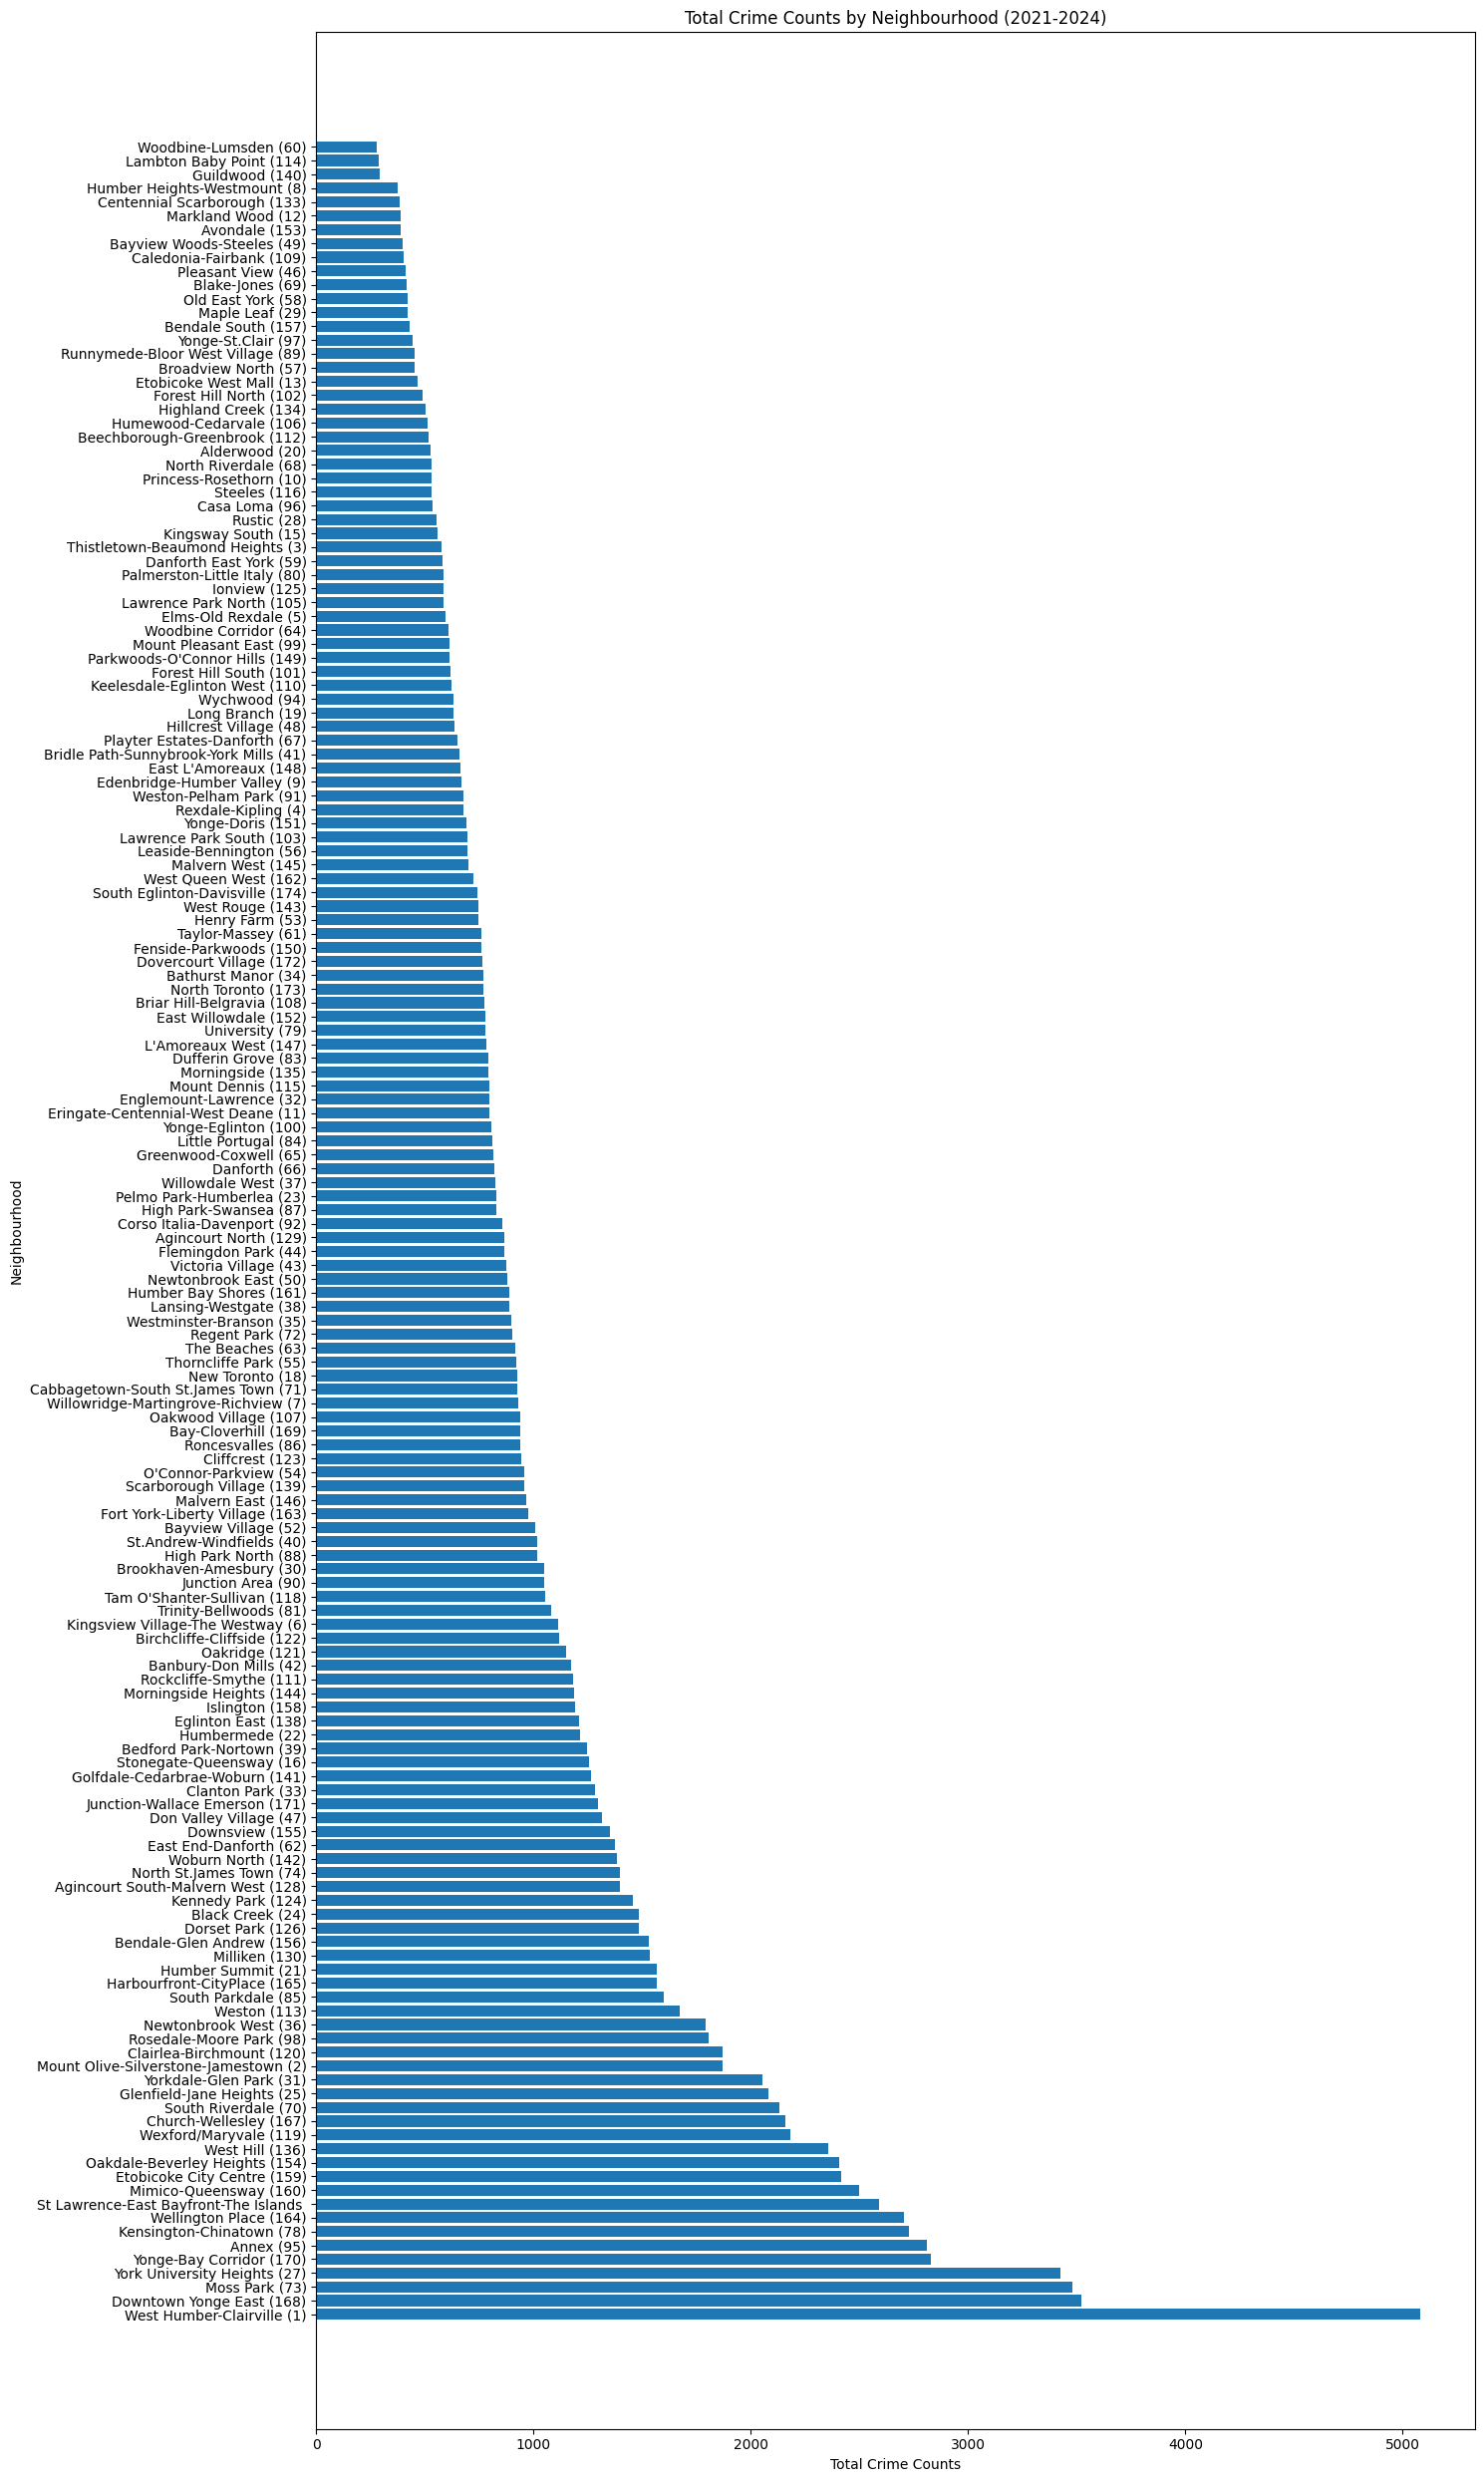

In [316]:
# Group by HOOD_158 and sum Crime_counts
hood_crime_counts = grouped_counts_all_crimes_with_zeros_short.groupby('HOOD_158', observed=False)['Crime_counts'].sum().reset_index()

# Merge with original dataframe to get NEIGHBOURHOOD_158
hood_crime_counts = hood_crime_counts.merge(df_mci[['HOOD_158', 'NEIGHBOURHOOD_158']].drop_duplicates(), on='HOOD_158')

# Sort by Crime_counts in descending order and take the top N (optional)
hood_crime_counts = hood_crime_counts.sort_values(by='Crime_counts', ascending=False) # set this to `True`, to switch order

# Create the bar plot
plt.figure(figsize=(15, 25))
plt.barh(hood_crime_counts['NEIGHBOURHOOD_158'], hood_crime_counts['Crime_counts'])
plt.ylabel('Neighbourhood')
plt.xlabel('Total Crime Counts')
plt.title('Total Crime Counts by Neighbourhood (2021-2024)')
plt.tight_layout()
plt.show()

**As you can see above, this shows that a single neighbourhood heavily outweights all the other neigbourhoods in terms of crime count.**

### What does it mean?

The bar chart provides a visual summary of the total crime counts for each neighbourhood over the period from 2021 to 2024. The length of each bar directly represents the total number of crimes reported in that specific neighbourhood. The fact that "West Humber-Clairville (1)" has the longest bar indicates that it has the highest cumulative number of crime incidents during this period compared to all other neighbourhoods.

In [317]:
grouped_counts_all_crimes_with_zeros_short.Crime_counts.describe()

,Crime_counts
count,32864.000000
mean,5.201010
std,4.617836
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,48.000000


**Lets describe what each of these values mean:**


*   `count`: there are a total of `32,864` entries, which is 52 Weeks x 4 Years x 158 neighbourhoods entries. That gives us a count of crimes per each neighbourhood, per week.
*   `mean`: avg number of crimes per each neighbourhood, per week is `~5.2`
*   `std`: std deviation number of crimes per each neighbourhood, per week is `~4.62`. Which means there is a moderate amount variation in weekly crime count.
*   `min`: there are some neighbourhood weeks with `0` crime counts
*   `25%`: 25% of the neighbourhood-weeks had `2` or fewer crimes
*   `50%`: 50% of the neighbourhood-weeks had `4` or fewer crimes
*   `75%`: 75% of the neighbourhood-weeks had `7` or fewer crimes
*   `max`: The largest amount of crimes commited in a single neighbourhood in a single week is `48`.




In [318]:
# Find the maximum crime count
max_crime_count = grouped_counts_all_crimes_with_zeros_short['Crime_counts'].max()

# Filter the DataFrame to show rows with the maximum crime count
rows_with_max_crime = grouped_counts_all_crimes_with_zeros_short[grouped_counts_all_crimes_with_zeros_short['Crime_counts'] == max_crime_count]

# Display the row(s)
display(rows_with_max_crime)

# Get the HOOD_158 and WEEK_SEQ for the row with the maximum crime count
hood_with_max_crime = rows_with_max_crime['HOOD_158'].iloc[0]
week_with_max_crime = rows_with_max_crime['WEEK_SEQ'].iloc[0]

# Filter the original df_mci DataFrame to show rows that match the neighbourhood and week
detailed_max_crime_data = df_mci[(df_mci['HOOD_158'] == hood_with_max_crime) &
                                 (df_mci['WEEK_SEQ'] == week_with_max_crime)]

# Display the filtered data
#display(detailed_max_crime_data)
#detailed_max_crime_data['MCI_CATEGORY'].unique()


,HOOD_158,WEEK_SEQ,Crime_counts
127,001,128,48


 > * I have taken the neighbourhood-week with the highest crime count and created a detailed view of that neighbourhood in that week (June 12th, 2023 - June 18th, 2023).
 * The point of interest is that, out of the five types of crime categories, all but one was committed.
 * The only type of crime excluded was `Theft Over` which refers to  *any theft over the value of $5000 (CAD)*.
 >
 > * **Why is this interesting?** When comparing this with the neighbourhood profiles, it would be interesting to see where in the avg. household income this neigbourhood will be.
 >* As per this data it suggests that `West Humber-Clairville (1)` would be in the lower end. (at least for the year 2023)

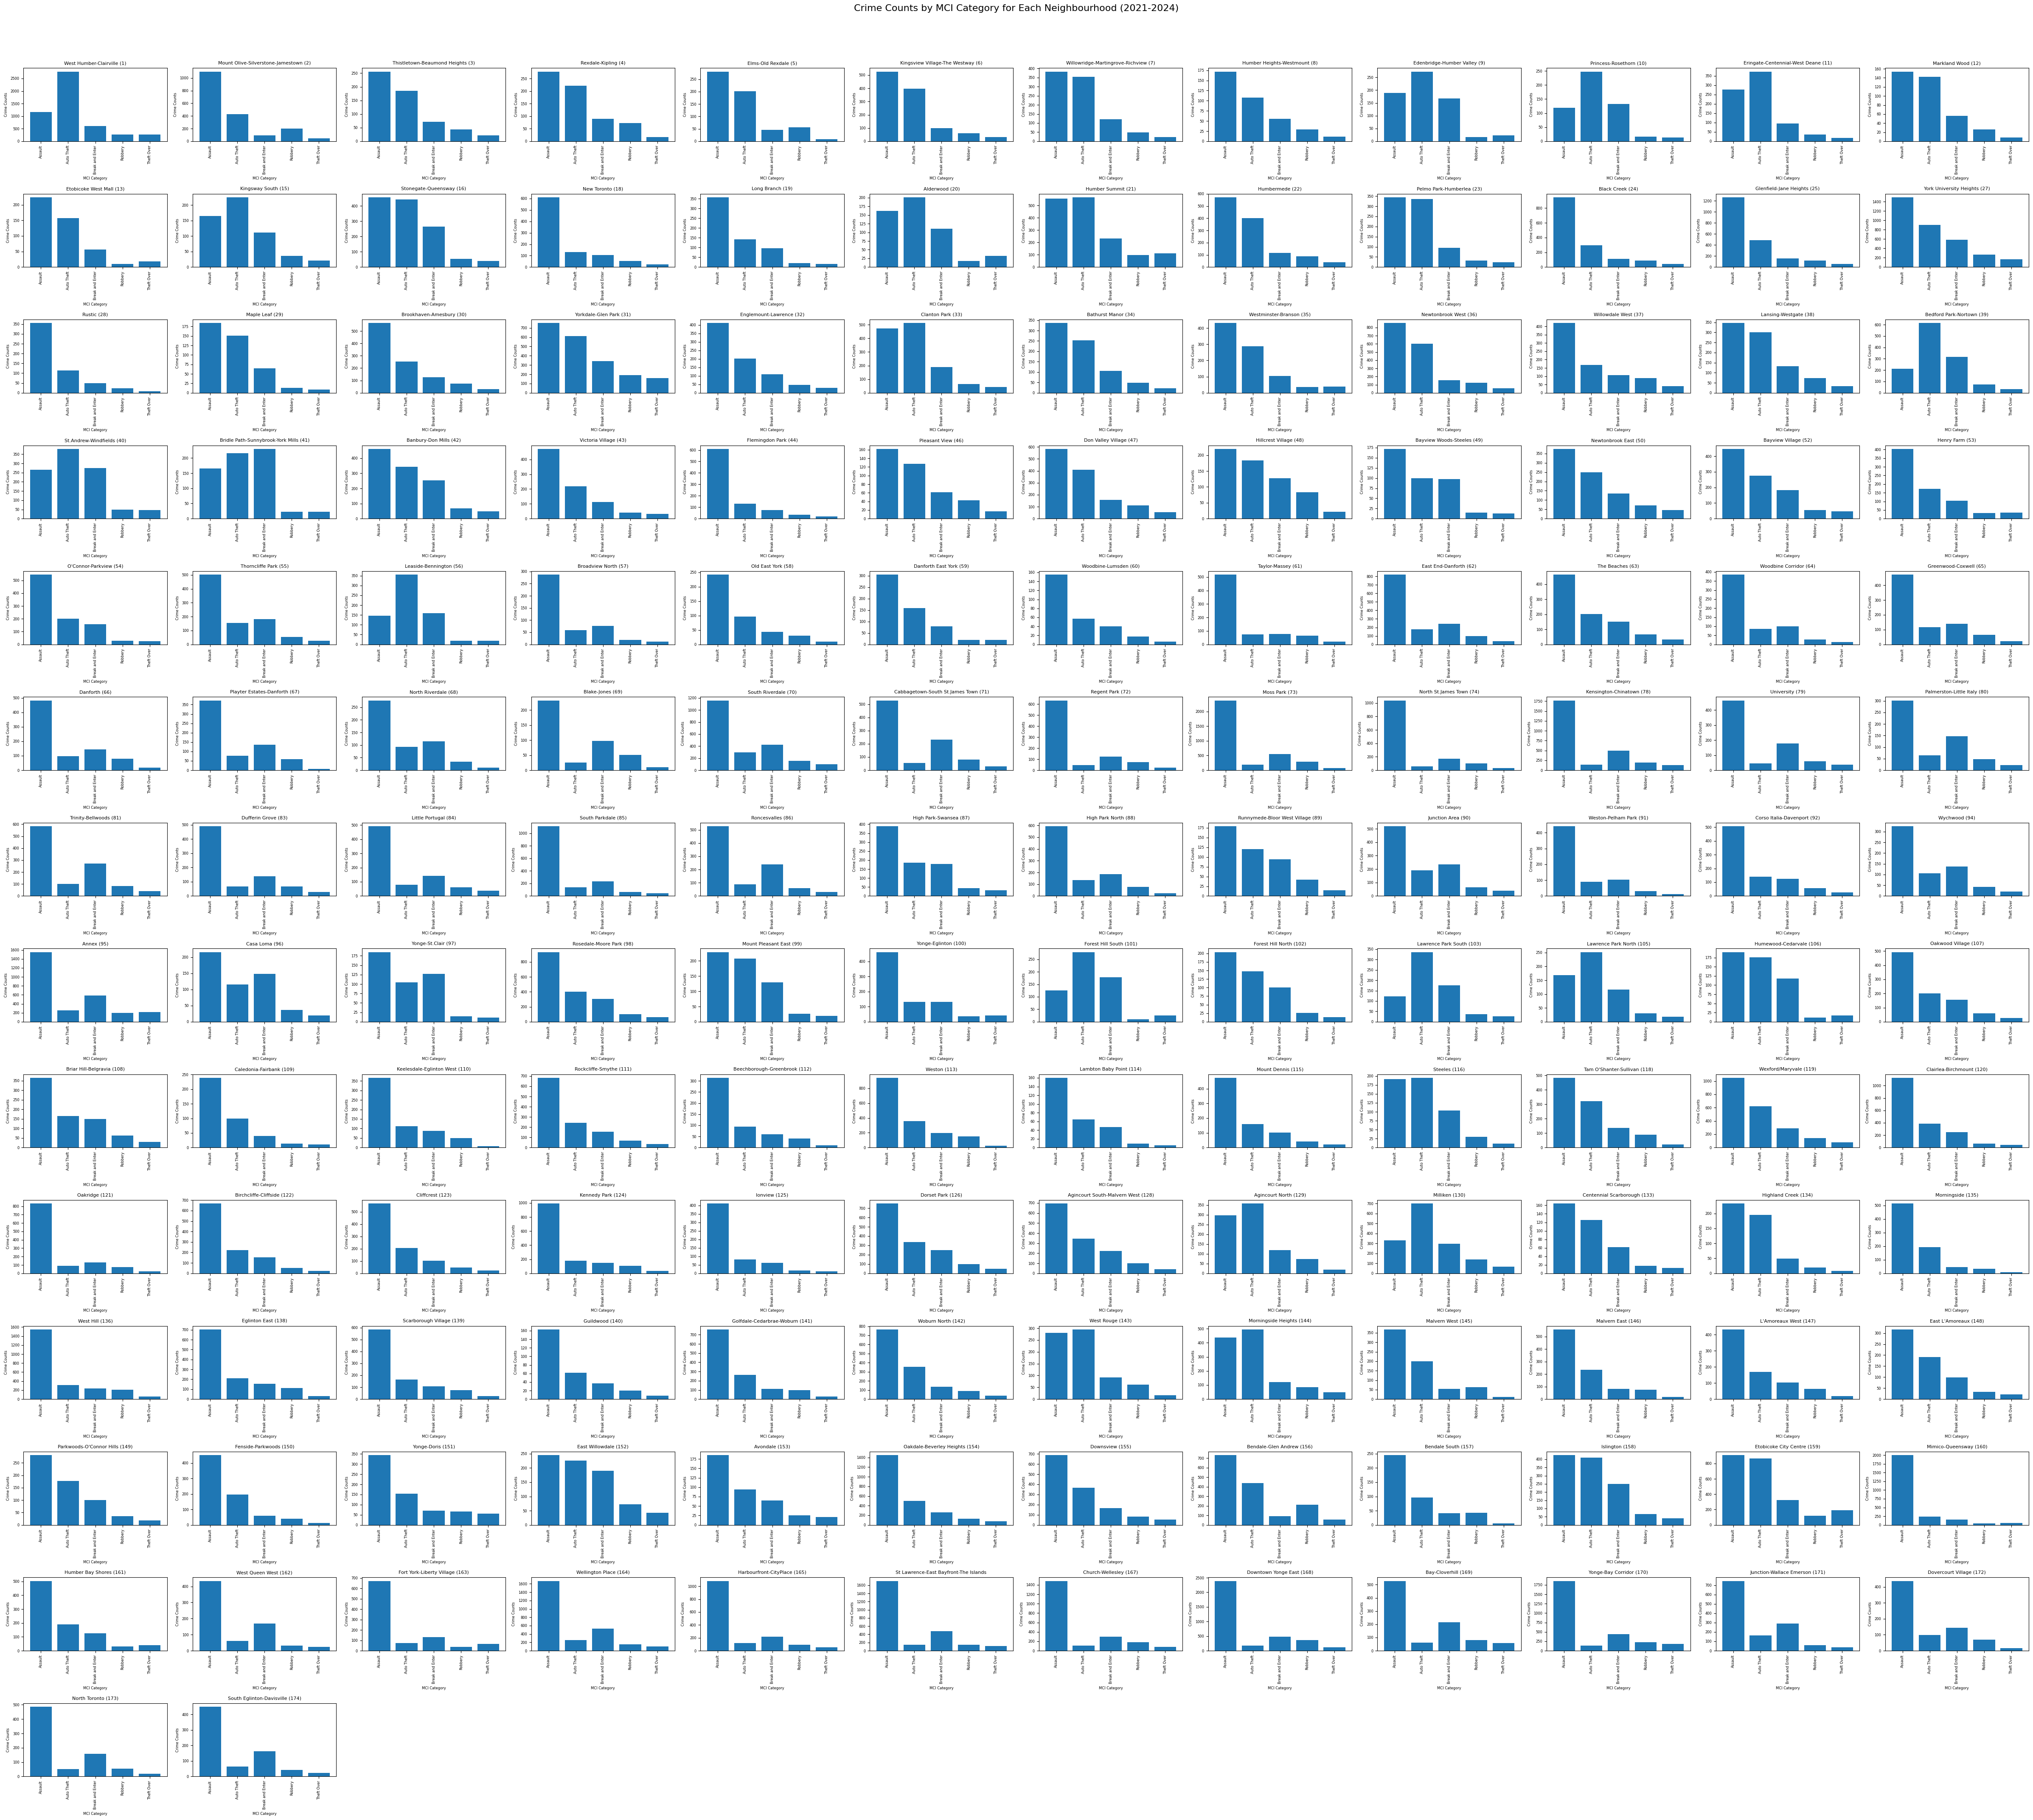

In [319]:

# Group by HOOD_158 and MCI_CATEGORY and sum Crime_counts
hood_mci_crime_counts = grouped_counts_mci_categories_with_zeros_short.groupby(['HOOD_158', 'MCI_CATEGORY'], observed=False)['Crime_counts'].sum().reset_index()

# Get unique HOOD_158 values
unique_hoods = hood_mci_crime_counts['HOOD_158'].unique()

# Determine the number of rows and columns for the grid
num_hoods = len(unique_hoods)
cols = 12
rows = (num_hoods + cols - 1) // cols

# Create the figure and axes for the grid
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Add a main title to the figure
fig.suptitle('Crime Counts by MCI Category for Each Neighbourhood (2021-2024)', fontsize=16, y=1.02) # Add suptitle here

# Merge with original dataframe to get NEIGHBOURHOOD_158 names
hood_names = df_mci[['HOOD_158', 'NEIGHBOURHOOD_158']].drop_duplicates()

# Iterate through each unique hood and generate a bar graph
for i, hood in enumerate(unique_hoods):
  ax = axes[i]
  hood_data = hood_mci_crime_counts[hood_mci_crime_counts['HOOD_158'] == hood]

  # Get the corresponding neighbourhood name
  neighbourhood_name = hood_names[hood_names['HOOD_158'] == hood]['NEIGHBOURHOOD_158'].iloc[0]

  ax.bar(hood_data['MCI_CATEGORY'], hood_data['Crime_counts'])
  ax.set_title(f'{neighbourhood_name}', fontsize=8) # Set the title to the neighbourhood name and reduce font size
  ax.set_xlabel('MCI Category', fontsize=6) # Reduce font size
  ax.set_ylabel('Crime Counts', fontsize=6) # Reduce font size
  ax.tick_params(axis='x', rotation=90, labelsize=6) # Rotate and reduce font size for x-axis labels
  ax.tick_params(axis='y', labelsize=6) # Reduce font size for y-axis labels


# Hide any unused subplots
for j in range(i + 1, len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



> **This confirms two assumptions:**
> 1.   The data needs to be normalized, as some neighbourhood's high crime count skew the others that aren't as high. This disparity makes direct comparisons of crime risk difficult without considering factors like population. Normalizing or standardizing the data (e.g., calculating crime rate per capita) would be a crucial next step for a fair comparison.
>
> 2.   The most common type of crime committed seems to be `Assault`. Let's prove this quantatively below.







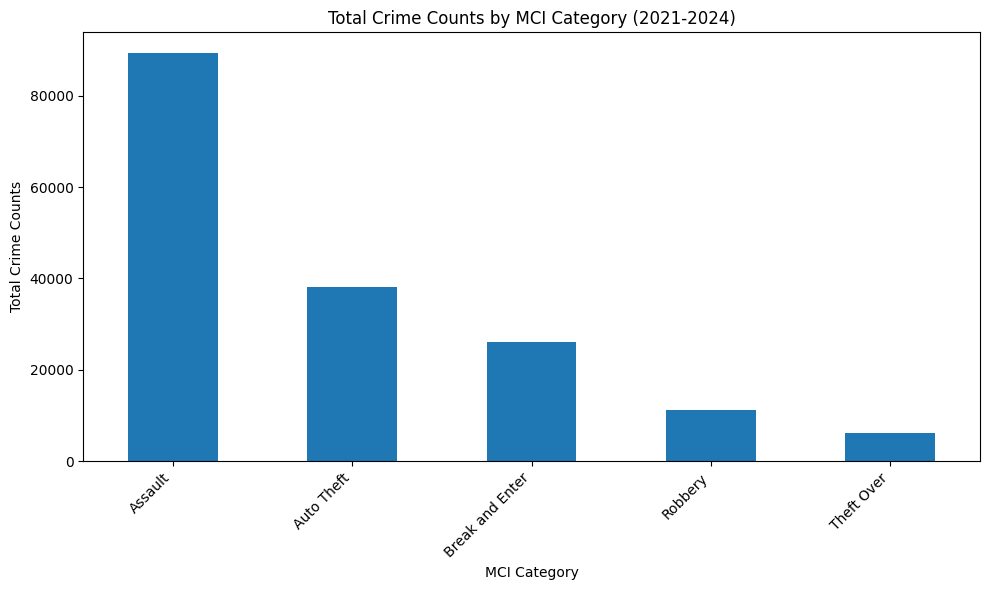

In [320]:
# Calculate the total count for each MCI_CATEGORY across all neighbourhoods
total_counts = grouped_counts_mci_categories_with_zeros_short.groupby('MCI_CATEGORY', observed=False)['Crime_counts'].sum()

# Sort them to see which category has the highest overall number of incidents.
total_counts.sort_values(ascending=False)

# Create a bar chart
plt.figure(figsize=(10, 6))
total_counts.plot(kind='bar')

plt.title('Total Crime Counts by MCI Category (2021-2024)')
plt.xlabel('MCI Category')
plt.ylabel('Total Crime Counts')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()




> As seen above, `Assault` far outweights any other type of crime. We will need to fix this with normalization.



## **10. Pilot analysis by joint Major Crime Indicator with neibourhood profile**

In [321]:
dfnp_selection = df_neighbourhood_profiles[['Total - Age groups of the population - 25% sample data']]
dfnp_selection = dfnp_selection.rename(columns={'Total - Age groups of the population - 25% sample data': 'POP_TOTAL'})
dfnp_selection['Neighbourhood_Number'] = df_neighbourhood_profiles[['Neighbourhood Number']]
dfnp_selection['POP_AGE_GROUP_0_14'] = df_neighbourhood_profiles[['0 to 14 years.1']]
dfnp_selection['POP_AGE_GROUP_15_64'] = df_neighbourhood_profiles[['15 to 64 years.1']]
dfnp_selection['POP_AGE_GROUP_65_'] = df_neighbourhood_profiles[['65 years and over.1']]
dfnp_selection['POP_AVG_AGE'] = df_neighbourhood_profiles[['Average age of the population']]
dfnp_selection['POP_MED_AGE'] = df_neighbourhood_profiles[['Median age of the population']]
dfnp_selection['MARRIED_%'] = df_neighbourhood_profiles['Married or living common-law'] / df_neighbourhood_profiles['Total - Marital status for the total population aged 15 years and over - 25% sample data']
dfnp_selection['POP_GOV_SUPP_SHARE'] = df_neighbourhood_profiles[['Government transfers (%)']]
dfnp_selection['AVG_HHOLD_SIZE'] = df_neighbourhood_profiles[['Average household size']]
dfnp_selection['AVG_TOT_HHOLD_INC'] = df_neighbourhood_profiles[['Average total income of household in 2020 ($)']]
dfnp_selection['OWNER_HHOLDS_%'] = df_neighbourhood_profiles['Owner'] / df_neighbourhood_profiles['Total - Private households by tenure - 25% sample data']
dfnp_selection['DW_W_CONDO_STATUS_%'] = df_neighbourhood_profiles['Condominium'] / df_neighbourhood_profiles['Total - Occupied private dwellings by condominium status - 25% sample data']
dfnp_selection['HHOLDS_UNSUIT_HOU_%'] = df_neighbourhood_profiles['Not suitable'] / df_neighbourhood_profiles['Total - Private households by housing suitability - 25% sample data']
dfnp_selection['DW_REQ_MAJ_REPAIR_%'] = df_neighbourhood_profiles['Major repairs needed'] / df_neighbourhood_profiles['Total - Occupied private dwellings by dwelling condition - 25% sample data']
dfnp_selection['SCTI_RAT_GT30_%'] = df_neighbourhood_profiles['Spending 30% or more of income on shelter costs'] / df_neighbourhood_profiles['Total - Owner and tenant households with household total income greater than zero, in non-farm, non-reserve private dwellings by shelter-cost-to-income ratio - 25% sample data']
dfnp_selection['HHOLD_OWN_MRTG_HOLD_%'] = df_neighbourhood_profiles[['% of owner households with a mortgage']]
dfnp_selection['HHOLD_OWN_SCTI_GT30_%'] = df_neighbourhood_profiles[['% of owner households spending 30% or more of its income on shelter costs']]
dfnp_selection['AVG_DW_VAL'] = df_neighbourhood_profiles[['Average value of dwellings ($)']]
dfnp_selection['HHOLDS_IN_SUBS_HOUS_%'] = df_neighbourhood_profiles[['% of tenant households in subsidized housing']] / 100
dfnp_selection['HHOLDS_OWN_AVG_MNTH_COST'] = df_neighbourhood_profiles[['Average monthly shelter costs for owned dwellings ($)']]
dfnp_selection['HHOLDS_RENT_AVG_MNTH_COST'] = df_neighbourhood_profiles[['Average monthly shelter costs for rented dwellings ($)']]
dfnp_selection['AVG_FAM_SIZE'] = df_neighbourhood_profiles[['Average size of census families']]
dfnp_selection['ONE_PAR_FAM_%'] = df_neighbourhood_profiles['Total one-parent families'] / df_neighbourhood_profiles['Total number of census families in private households - 25% sample data']
dfnp_selection['AVG_NUM_CH_PER_FAM'] = df_neighbourhood_profiles[['Average number of children in census families with children']]
dfnp_selection['HHOLD_FIRST_LANG_EN_%'] = df_neighbourhood_profiles['English'] / df_neighbourhood_profiles['Total - First official language spoken for the population in private households - 25% sample data']
dfnp_selection['HHOLD_FIRST_LANG_FR_%'] = df_neighbourhood_profiles['French'] / df_neighbourhood_profiles['Total - First official language spoken for the population in private households - 25% sample data']
dfnp_selection['HHOLD_FIRST_LANG_ENFR_%'] = df_neighbourhood_profiles['English and French'] / df_neighbourhood_profiles['Total - First official language spoken for the population in private households - 25% sample data']
dfnp_selection['HHOLD_FIRST_LANG_OTH_%'] = df_neighbourhood_profiles['Neither English nor French'] / df_neighbourhood_profiles['Total - First official language spoken for the population in private households - 25% sample data']
dfnp_selection['POP_NONCITIZ_%'] = df_neighbourhood_profiles['Not Canadian citizens'] / df_neighbourhood_profiles['Total - Citizenship for the population in private households - 25% sample data']
dfnp_selection['POP_NON_IMMIGR_%'] = df_neighbourhood_profiles['Non-immigrants'] / df_neighbourhood_profiles['Total - Immigrant status and period of immigration for the population in private households - 25% sample data']
dfnp_selection['POP_IMMIGR_%'] = df_neighbourhood_profiles['Immigrants'] / df_neighbourhood_profiles['Total - Immigrant status and period of immigration for the population in private households - 25% sample data']
dfnp_selection['POP_TEMP_RES_%'] = df_neighbourhood_profiles['Non-permanent residents'] / df_neighbourhood_profiles['Total - Immigrant status and period of immigration for the population in private households - 25% sample data']
dfnp_selection['PARTICIP_RATE'] = df_neighbourhood_profiles[['Participation rate']]
dfnp_selection['UNEMPLOY_RATE'] = df_neighbourhood_profiles[['Unemployment rate']]
dfnp_selection['POP_NO_EDUC_%'] = df_neighbourhood_profiles['No certificate, diploma or degree.1'] / df_neighbourhood_profiles['Total - Highest certificate, diploma or degree for the population aged 25 to 64 years in private households - 25% sample data']
dfnp_selection['POP_HIGH_SCH_EDUC_%'] = df_neighbourhood_profiles['High (secondary) school diploma or equivalency certificate.1'] / df_neighbourhood_profiles['Total - Highest certificate, diploma or degree for the population aged 25 to 64 years in private households - 25% sample data']
dfnp_selection['POP_POSTSEC_EDUC_%'] = df_neighbourhood_profiles['Postsecondary certificate, diploma or degree.1'] / df_neighbourhood_profiles['Total - Highest certificate, diploma or degree for the population aged 25 to 64 years in private households - 25% sample data']
dfnp_selection['COMMUTE_CAR_%'] = df_neighbourhood_profiles['Car, truck or van'] / df_neighbourhood_profiles['Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_TRANSIT_%'] = df_neighbourhood_profiles['Public transit'] / df_neighbourhood_profiles['Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_WALK_%'] = df_neighbourhood_profiles['Walked'] / df_neighbourhood_profiles['Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_CYCLE_%'] = df_neighbourhood_profiles['Bicycle'] / df_neighbourhood_profiles['Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_OTHER_%'] = df_neighbourhood_profiles['Other method'] / df_neighbourhood_profiles['Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_LT_30_MIN_%'] = (df_neighbourhood_profiles['Less than 15 minutes'] + df_neighbourhood_profiles['15 to 29 minutes']) / df_neighbourhood_profiles['Total - Commuting duration for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_30_59_MIN_%'] = (df_neighbourhood_profiles['30 to 44 minutes'] + df_neighbourhood_profiles['45 to 59 minutes']) / df_neighbourhood_profiles['Total - Commuting duration for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_GT_59_MIN_%'] = df_neighbourhood_profiles['60 minutes and over'] / df_neighbourhood_profiles['Total - Commuting duration for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_5_6_AM_%'] = df_neighbourhood_profiles['Between 5 a.m. and 5:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_6_7_AM_%'] = df_neighbourhood_profiles['Between 6 a.m. and 6:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_7_8_AM_%'] = df_neighbourhood_profiles['Between 7 a.m. and 7:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_8_9_AM_%'] = df_neighbourhood_profiles['Between 8 a.m. and 8:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_9_AM_noon_%'] = df_neighbourhood_profiles['Between 9 a.m. and 11:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection['COMMUTE_START_noon_5_AM_%'] = df_neighbourhood_profiles['Between 12 p.m. and 4:59 a.m.'] / df_neighbourhood_profiles['Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data']
dfnp_selection.head(5)

scalingColumns = ['POP_AGE_GROUP_0_14','POP_AGE_GROUP_15_64','POP_AGE_GROUP_65_','POP_AVG_AGE','POP_MED_AGE','MARRIED_%','AVG_HHOLD_SIZE','AVG_TOT_HHOLD_INC',
                  'AVG_DW_VAL','HHOLDS_OWN_AVG_MNTH_COST','HHOLDS_RENT_AVG_MNTH_COST','AVG_FAM_SIZE','AVG_NUM_CH_PER_FAM'];


In [322]:
# Select the Neighbourhood Number and Total Population columns
df_population = df_neighbourhood_profiles[['Neighbourhood Number', 'Total - Age groups of the population - 25% sample data']].copy()

# Rename the population column for clarity
df_population = df_population.rename(columns={'Total - Age groups of the population - 25% sample data': 'Population_2021'})
# fill na with 0 for population column
df_population['Population_2021'] = (
    pd.to_numeric(df_population['Population_2021'], errors='coerce')
    .fillna(0)
    .astype(float)
)
# Convert 'Neighbourhood Number' to string and pad with leading zeros to match 'HOOD_158' format
df_population['Neighbourhood Number'] = df_population['Neighbourhood Number'].astype(str).str.zfill(3)

# Display the first few rows of the new DataFrame
display(df_population.head())

Neighbourhood Name,Neighbourhood Number,Population_2021
West Humber-Clairville,001,33300.0
Mount Olive-Silverstone-Jamestown,002,31345.0
Thistletown-Beaumond Heights,003,9850.0
Rexdale-Kipling,004,10375.0
Elms-Old Rexdale,005,9355.0


In [323]:
# Now attempt the merge again with the corrected 'Neighbourhood Number' format
df_crime_population = grouped_counts_all_crimes_with_zeros_short.merge(
    df_population,
    left_on='HOOD_158',  # Column in grouped_counts_all_crimes_with_zeros_short
    right_on='Neighbourhood Number',  # Column in df_population
    how='inner' # Use an inner merge to keep only matching neighbourhoods
)

# Drop the redundant 'Neighbourhood Number' column after merging
df_crime_population = df_crime_population.drop('Neighbourhood Number', axis=1)
# Calculate the crime rate per 1,000 people
df_crime_population['Crime_Rate_Per_1000'] = (df_crime_population['Crime_counts'] / df_crime_population['Population_2021']) * 1000

# Display the first few rows and shape of the merged DataFrame
display(df_crime_population.head())
print(df_crime_population.shape)

,HOOD_158,WEEK_SEQ,Crime_counts,Population_2021,Crime_Rate_Per_1000
0,001,1,19,33300.0,0.570571
1,001,2,11,33300.0,0.330330
2,001,3,12,33300.0,0.360360
3,001,4,20,33300.0,0.600601
4,001,5,12,33300.0,0.360360


(32864, 5)


In [324]:
# 1) Load & rename
crime_df = grouped_counts_mci_categories_with_zeros_occ_short.rename(columns={'Crime_counts':'Count'})

# 2) Merge population & cast to numeric
crime_df = (
    crime_df
    .merge(df_population[['Neighbourhood Number','Population_2021']],
           left_on='HOOD_158', right_on='Neighbourhood Number', how='left')
    .drop('Neighbourhood Number', axis=1)
)

# 3) Ensure numeric & fill
for col in ['Count','Population_2021']:
    crime_df[col] = (
        pd.to_numeric(crime_df[col], errors='coerce')
        .fillna(0)
        .astype(float)
    )

# 4) Compute per‑capita rate
crime_df['Crime_Rate_Per_1000'] = (
    (crime_df['Count'] / crime_df['Population_2021']) * 1000
).fillna(0).astype(float)

In [325]:
# 5) Build full panel and fill
all_hoods      = crime_df['HOOD_158'].unique()
all_weeks      = crime_df['OCC_WEEK_SEQ'].unique()
all_categories = crime_df['MCI_CATEGORY'].unique()

full_idx = pd.MultiIndex.from_product(
    [all_hoods, all_weeks, all_categories],
    names=['HOOD_158','OCC_WEEK_SEQ','MCI_CATEGORY']
)
panel = (
    full_idx
    .to_frame(index=False)
    .merge(crime_df, on=['HOOD_158','OCC_WEEK_SEQ','MCI_CATEGORY'], how='left')
)

panel['Count'] = panel['Count'].fillna(0).astype(float)
panel['Population_2021'] = (
    panel
    .groupby('HOOD_158', observed=True)['Population_2021']
    .transform(lambda x: x.fillna(x.mean()))
    .fillna(0)
    .astype(float)
)
panel['Crime_Rate_Per_1000'] = (
    (panel['Count'] / panel['Population_2021']) * 1000
).fillna(0).astype(float)

# ─── Special Case Handling ───
# 1) Zero‑population flag
zero_pop_hoods = panel.loc[panel['Population_2021']==0, 'HOOD_158'].unique()
panel['zero_population_flag'] = panel['HOOD_158'].isin(zero_pop_hoods)


# 6) Map real date → quarter
week_map = (
    df_mci_occ[['OCC_WEEK_SEQ','OCC_DATE']]
    .drop_duplicates()
    .assign(OCC_DATE=lambda df: pd.to_datetime(df['OCC_DATE']))
)
week_map['OCC_YEAR']    = week_map['OCC_DATE'].dt.year
week_map['OCC_QUARTER'] = week_map['OCC_DATE'].dt.quarter

panel = panel.merge(week_map, on='OCC_WEEK_SEQ', how='left')

In [326]:
# CREATE final_features_df with temporal features

# 2) Volatility + zero‑crime flag
volatility = (
    panel
    .groupby(['HOOD_158','MCI_CATEGORY'], observed=True)
    .agg(
        cv_counts = ('Count', lambda x: variation(x) if x.mean()!=0 else np.nan),
        cv_rates  = ('Crime_Rate_Per_1000', lambda x: variation(x) if x.mean()!=0 else np.nan),
    )
    .reset_index()
)
volatility['zero_crime_flag'] = volatility['cv_counts'].isna()

# 7) Seasonality: mean rate by true calendar quarter
seasonality = (
    panel
    .groupby(['HOOD_158','MCI_CATEGORY','OCC_YEAR','OCC_QUARTER'], observed=True)['Crime_Rate_Per_1000']
    .mean()
    .unstack(['OCC_QUARTER','OCC_YEAR'])
)
seasonality.columns = [
    f"mean_rate_Q{q}_{y}"
    for q,y in seasonality.columns
]
seasonality = seasonality.reset_index()

# 8) Volatility: CV on counts & rates
volatility = (
    panel
    .groupby(['HOOD_158','MCI_CATEGORY'], observed=True)
    .agg(
        cv_counts = ('Count', lambda x: variation(x) if x.mean()!=0 else np.nan),
        cv_rates  = ('Crime_Rate_Per_1000', lambda x: variation(x) if x.mean()!=0 else np.nan),
    )
    .reset_index()
)

# 9) Trend: YoY % change on annual average rate
annual_rates = (
    panel
    .groupby(['HOOD_158','MCI_CATEGORY','OCC_YEAR'], observed=True)['Crime_Rate_Per_1000']
    .mean()
    .unstack('OCC_YEAR')
)
for prev, nxt in zip(annual_rates.columns[:-1], annual_rates.columns[1:]):
    annual_rates[f"YoY_Rate_Change_{prev}_vs_{nxt}"] = (
        (annual_rates[nxt] - annual_rates[prev]) / annual_rates[prev] * 100
    )
trend = annual_rates.filter(like="YoY_Rate_Change").reset_index()

# 10) Concentration: HHI on rates
concentration = (
    panel
    .groupby(['HOOD_158','MCI_CATEGORY'], observed=True)['Crime_Rate_Per_1000']
    .apply(lambda x: np.sum((x/x.sum())**2) if x.sum()>0 else 0)
    .rename('hhi_rate_concentration')
    .reset_index()
)

# 11) Merge all temporal features
temp_feats = (
    seasonality
    .merge(volatility,    on=['HOOD_158','MCI_CATEGORY'])
    .merge(trend,         on=['HOOD_158','MCI_CATEGORY'])
    .merge(concentration, on=['HOOD_158','MCI_CATEGORY'])
)

# 12) Fourier features with peak month
weekly_totals = panel.groupby(['HOOD_158','OCC_WEEK_SEQ'], observed=True)['Crime_Rate_Per_1000'].sum().reset_index()
fourier_list = []
for hood, grp in weekly_totals.groupby('HOOD_158', observed=True):
    rates = grp.sort_values('OCC_WEEK_SEQ')['Crime_Rate_Per_1000'].values
    N     = len(rates)
    yf    = fft(rates)
    xf    = fftfreq(N)
    feats = {'HOOD_158': hood}
    for label, freq in [('yearly',1/52), ('half',1/26)]:
        idx = np.argmin(np.abs(xf - freq))
        if 0 < idx < N/2:
            amp   = np.abs(yf[idx]) * 2 / N
            phase = np.angle(yf[idx]) % (2*np.pi)
            months = 12 if label=='yearly' else 6
            feats[f'{label}_amp']        = amp
            feats[f'{label}_peak_month'] = (phase/(2*np.pi)) * months
    fourier_list.append(feats)
fourier_df = pd.DataFrame(fourier_list)

# 13) Final merge
final_features_df = temp_feats.merge(fourier_df, on='HOOD_158', how='left')

# ─── Merge Special‑Case Flags into final_features_df ───
# 1) Zero‑population flag (per neighbourhood)
if 'zero_population_flag' not in panel:
    panel['zero_population_flag'] = panel['Population_2021'] == 0

hood_flags = panel[['HOOD_158','zero_population_flag']].drop_duplicates()

# 2) Zero‑crime flag (per neighbourhood×category)
#   True if that hood/category never had any incidents (Count sum == 0)
vol_flags = (
    panel
    .groupby(['HOOD_158','MCI_CATEGORY'], observed=True)
    .agg(zero_crime_flag=('Count', lambda x: x.sum() == 0))
    .reset_index()
)

# 3) Merge both flags in
final_features_df = (
    final_features_df
    .merge(hood_flags, on='HOOD_158', how='left')
    .merge(vol_flags,  on=['HOOD_158','MCI_CATEGORY'], how='left')
)

# ─── Scale & Z‑score Crime Features ───
# 1) Identify crime‐block columns as before
season_cols = [c for c in final_features_df.columns if re.match(r"mean_rate_Q[1-4]_(2021|2022|2023)$", c)]
trend_cols  = [c for c in final_features_df.columns
               if re.match(r"YoY_Rate_Change_\d{4}_vs_\d{4}$", c) and not c.endswith("_vs_2024")]
vol_cols    = ['cv_counts','cv_rates']
concen_cols = ['hhi_rate_concentration']
fourier_cols= [c for c in final_features_df.columns if c.endswith('_amp') or c.endswith('_peak_month')]

crime_features = season_cols + trend_cols + vol_cols + concen_cols + fourier_cols

# 2) Extract and clean infinities → NaN
X_crime = final_features_df[crime_features].replace([np.inf, -np.inf], np.nan)

# 3) Impute NaN → 0 (interpreted as “no change” for YOY and “no variability” for CV)
X_crime_filled = X_crime.fillna(0)

# # 4) Fit StandardScaler on the cleaned crime block
# scaler_crime = StandardScaler()
# scaler_crime.fit(X_crime_filled)

# # 5) Transform & append z‑score columns
# scaled = scaler_crime.transform(X_crime_filled)
# for idx, feat in enumerate(crime_features):
#     final_features_df[f"{feat}_z"] = scaled[:, idx]

# 6) Convert HOOD_158 to int
final_features_df['HOOD_158'] = final_features_df['HOOD_158'].astype(int)

# 7) Quick sanity check
print("Features with flags:")
display(final_features_df.head())
print("\nNew shape:", final_features_df.shape)
print("Crime features (cleaned) preview (no z-scores shown here):")
display(final_features_df[crime_features].head())

Features with flags:


,HOOD_158,MCI_CATEGORY,mean_rate_Q1_2021,mean_rate_Q2_2021,mean_rate_Q3_2021,mean_rate_Q4_2021,mean_rate_Q1_2022,mean_rate_Q2_2022,mean_rate_Q3_2022,mean_rate_Q4_2022,...,YoY_Rate_Change_2021_vs_2022,YoY_Rate_Change_2022_vs_2023,YoY_Rate_Change_2023_vs_2024,hhi_rate_concentration,yearly_amp,yearly_peak_month,half_amp,half_peak_month,zero_population_flag,zero_crime_flag
0,1,Assault,0.121788,0.11979,0.165165,0.152109,0.184184,0.12342,0.144601,0.158963,...,9.176471,19.558190,2.558136,0.000844,0.180156,1.991694,0.069645,3.774705,False,False
1,1,Auto Theft,0.193861,0.22440,0.344366,0.381904,0.402736,0.41745,0.451103,0.538582,...,57.888698,6.413517,-21.659058,0.000800,0.180156,1.991694,0.069645,3.774705,False,False
2,1,Break and Enter,0.043043,0.05346,0.046677,0.088458,0.074741,0.05742,0.084867,0.088458,...,31.773050,61.571582,-27.713036,0.001063,0.180156,1.991694,0.069645,3.774705,False,False
3,1,Robbery,0.022689,0.03795,0.032315,0.029704,0.053720,0.02706,0.050268,0.032641,...,33.243968,9.657948,-19.120670,0.001666,0.180156,1.991694,0.069645,3.774705,False,False
4,1,Theft Over,0.025359,0.02937,0.029704,0.045045,0.025359,0.03399,0.038843,0.037864,...,5.076142,30.676329,-5.619022,0.001195,0.180156,1.991694,0.069645,3.774705,False,False



New shape: (790, 30)
Crime features (cleaned) preview (no z-scores shown here):


,mean_rate_Q1_2021,mean_rate_Q2_2021,mean_rate_Q3_2021,mean_rate_Q4_2021,mean_rate_Q1_2022,mean_rate_Q2_2022,mean_rate_Q3_2022,mean_rate_Q4_2022,mean_rate_Q1_2023,mean_rate_Q2_2023,...,mean_rate_Q4_2023,YoY_Rate_Change_2021_vs_2022,YoY_Rate_Change_2022_vs_2023,cv_counts,cv_rates,hhi_rate_concentration,yearly_amp,yearly_peak_month,half_amp,half_peak_month
0,0.121788,0.11979,0.165165,0.152109,0.184184,0.12342,0.144601,0.158963,0.117117,0.182820,...,0.212822,9.176471,19.558190,0.482614,0.482614,0.000844,0.180156,1.991694,0.069645,3.774705
1,0.193861,0.22440,0.344366,0.381904,0.402736,0.41745,0.451103,0.538582,0.653320,0.542851,...,0.373090,57.888698,6.413517,0.410393,0.410393,0.000800,0.180156,1.991694,0.069645,3.774705
2,0.043043,0.05346,0.046677,0.088458,0.074741,0.05742,0.084867,0.088458,0.098765,0.119130,...,0.118162,31.773050,61.571582,0.743875,0.743875,0.001063,0.180156,1.991694,0.069645,3.774705
3,0.022689,0.03795,0.032315,0.029704,0.053720,0.02706,0.050268,0.032641,0.060727,0.031680,...,0.031662,33.243968,9.657948,1.197488,1.197488,0.001666,0.180156,1.991694,0.069645,3.774705
4,0.025359,0.02937,0.029704,0.045045,0.025359,0.03399,0.038843,0.037864,0.044044,0.030030,...,0.057775,5.076142,30.676329,0.863733,0.863733,0.001195,0.180156,1.991694,0.069645,3.774705


# Socio‑Economic: Select Core Indicators

In [327]:
# ─── B) Subset, Impute & Prune Socio‑Economic Indicators ───


# 1) pick only the direct, easy‑to‑explain indicators
candidate_cols = [
    'Neighbourhood Number',
    'Median total income in 2020 among recipients ($)',
    'Unemployment rate',
    'Average household size',
    '% of owner households spending 30% or more of its income on shelter costs',
    '% in core housing need'
]

socio = (
    df_neighbourhood_profiles[candidate_cols]
      .rename(columns={'Neighbourhood Number':'HOOD_158'})
)

# 2) drop any feature with >50% missing, then median‑impute the rest
missing_pct = socio.drop('HOOD_158', axis=1).isna().mean()
keep_cols   = missing_pct[missing_pct < 0.5].index.tolist()

socio = socio[['HOOD_158'] + keep_cols].copy()
socio[keep_cols] = socio[keep_cols].fillna(socio[keep_cols].median())

# 3) prune away one of any two features whose |corr|>0.8
corr  = socio[keep_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if (upper[c] > 0.8).any()]
socio = socio.drop(columns=to_drop)

print("→ retained socio‑econ features:", socio.columns.tolist())


# ─── C) Scale to Z‑Scores ───

feat_cols = [c for c in socio.columns if c!='HOOD_158']
scaler    = StandardScaler()

socio_z = socio.copy()
socio_z[feat_cols] = scaler.fit_transform(socio_z[feat_cols])
# cast HOOD_158 to int for consistency
socio_z['HOOD_158'] = socio_z['HOOD_158'].astype(int)

print("→ sample z‑scored profiles:")
display(socio_z.head())


→ retained socio‑econ features: ['HOOD_158', 'Median total income in 2020 among recipients ($)', 'Average household size', '% of owner households spending 30% or more of its income on shelter costs', '% in core housing need']
→ sample z‑scored profiles:


/tmp/ipython-input-327-2988014132.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  socio[keep_cols] = socio[keep_cols].fillna(socio[keep_cols].median())


Neighbourhood Name,HOOD_158,Median total income in 2020 among recipients ($),Average household size,% of owner households spending 30% or more of its income on shelter costs,% in core housing need
West Humber-Clairville,1,-0.823400,1.533931,-0.410600,-0.346633
Mount Olive-Silverstone-Jamestown,2,-1.216176,1.773182,0.535710,1.240503
Thistletown-Beaumond Heights,3,-0.901955,1.294681,-0.174023,-0.086059
Rexdale-Kipling,4,-0.823400,0.337677,-1.146619,-0.607208
Elms-Old Rexdale,5,-0.744845,1.055430,-0.147736,0.316648


In [328]:
def compute_features(up_to_year):
    # ─── Helpers ─────────────────────────────────────────────
    def find_column(df, keyword, df_name):
        matches = [c for c in df.columns if keyword.lower() in c.lower()]
        if not matches:
            raise KeyError(f"No column containing '{keyword}' in {df_name}. Available: {df_mci_raw.columns.tolist()}")
        return matches[0]

    # ─── 1) Prepare raw crime occurrences ───
    events = df_mci_occ.copy()
    date_col = find_column(events, "date", "df_mci_occ")
    events["OCC_DATE"] = pd.to_datetime(events[date_col], errors="coerce")
    events["OCC_YEAR"] = events["OCC_DATE"].dt.year

    # ─── 2) Build weekly panel ───
    wk_ev = find_column(events, "week", "df_mci_occ")
    wk_pf = find_column(df_crime_population, "week", "df_crime_population")
    week_map = events[[wk_ev, "OCC_DATE"]].drop_duplicates()
    weekly_panel = (
        df_crime_population
        .merge(week_map, left_on=wk_pf, right_on=wk_ev, how="left")
        .drop(columns=[wk_ev] if wk_ev!=wk_pf else [])
        .rename(columns={wk_pf: "WEEK_SEQ"})
    )
    weekly_panel["OCC_DATE"] = pd.to_datetime(weekly_panel["OCC_DATE"], errors="coerce")
    weekly_panel["OCC_YEAR"] = weekly_panel["OCC_DATE"].dt.year
    weekly_panel = weekly_panel[weekly_panel["OCC_YEAR"] <= up_to_year]
    weekly_panel["Crime_Rate_Per_1000"] = pd.to_numeric(
        weekly_panel["Crime_Rate_Per_1000"], errors="coerce"
    )

    # ─── 3) Build your feature‐matrix *without* any YoY columns ───
    # first drop ALL columns in final_features_df whose name contains "YoY"
    feats = final_features_df.drop(
        columns=[c for c in final_features_df.columns if "YoY" in c or "Rate_Change" in c],
        errors="ignore"
    )
    socio_matrix = (
        feats
        .merge(socio_z, on="HOOD_158", how="left")
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=[
            "Median total income in 2020 among recipients ($)",
            "yearly_amp",
            "yearly_peak_month"
        ])
    )

    # ─── 4) Annual rates ───
    ev_upto = events[events["OCC_YEAR"] <= up_to_year]
    annual_counts = (
        ev_upto
        .groupby(["HOOD_158","OCC_YEAR","MCI_CATEGORY"], observed=False)
        .size().reset_index(name="Annual_Crime_Count")
    )
    annual_rates = (
        annual_counts
        .merge(
            df_population[["Neighbourhood Number","Population_2021"]],
            left_on="HOOD_158", right_on="Neighbourhood Number", how="left"
        )
        .drop(columns="Neighbourhood Number")
    )
    annual_rates["Annual_Crime_Rate_Per_1000"] = (
        annual_rates["Annual_Crime_Count"]
        .div(annual_rates["Population_2021"])
        .replace([np.inf, -np.inf], 0)
        .fillna(0)
        .mul(1000)
    )
    events_with_rate = ev_upto.merge(
        annual_rates[
          ["HOOD_158","OCC_YEAR","MCI_CATEGORY","Annual_Crime_Rate_Per_1000"]
        ],
        on=["HOOD_158","OCC_YEAR","MCI_CATEGORY"], how="left"
    )

    # ─── 5) Neighbourhood‐level average rate ───
    neighbourhood_rate = (
        weekly_panel
        .groupby("HOOD_158", observed=False)["Crime_Rate_Per_1000"]
        .mean().reset_index()
        .merge(
            events[["HOOD_158","NEIGHBOURHOOD_158"]].drop_duplicates(),
            on="HOOD_158"
        )
    )
    neighbourhood_rate['HOOD_158'] = neighbourhood_rate['HOOD_158'].astype(int)

    # ─── 6) Category‐level average rate ───
    category_panel = (
        grouped_counts_mci_categories_with_zeros_short
        .merge(
            df_population[["Neighbourhood Number","Population_2021"]],
            left_on="HOOD_158", right_on="Neighbourhood Number", how="inner"
        ).drop(columns="Neighbourhood Number")
    )
    category_panel["Crime_Rate_Category_Per_1000"] = (
        category_panel["Crime_counts"]
        .div(category_panel["Population_2021"])
        .replace([np.inf, -np.inf], 0)
        .fillna(0)
        .mul(1000)
    )
    category_rate = (
        category_panel
        .groupby(["HOOD_158","MCI_CATEGORY"], observed=False)["Crime_Rate_Category_Per_1000"]
        .mean().reset_index()
        .merge(
            events[["HOOD_158","NEIGHBOURHOOD_158"]].drop_duplicates(),
            on="HOOD_158"
        )
    )

    # ─── 7) Overall weekly trend ───
    overall_trend = (
        weekly_panel
        .groupby("WEEK_SEQ", observed=False)["Crime_Rate_Per_1000"]
        .mean().reset_index()
    )

    return {
        "features": socio_matrix,
        "annual_crime_rate": annual_rates,
        "df_mci_with_rate": events_with_rate,
        "hood_crime_rate": neighbourhood_rate,
        "average_crime_rate_category": category_rate,
        "overall_crime_trend": overall_trend,
    }


In [329]:
df_crime_population.columns.tolist()


['HOOD_158',
 'WEEK_SEQ',
 'Crime_counts',
 'Population_2021',
 'Crime_Rate_Per_1000']

In [330]:
# build your train/test sets
data_2023 = compute_features(2023)
#data_2024 = compute_features(2024)
data_2023.values()

dict_values([     HOOD_158     MCI_CATEGORY  mean_rate_Q1_2021  mean_rate_Q2_2021  \
0           1          Assault           0.121788           0.119790   
1           1       Auto Theft           0.193861           0.224400   
2           1  Break and Enter           0.043043           0.053460   
3           1          Robbery           0.022689           0.037950   
4           1       Theft Over           0.025359           0.029370   
..        ...              ...                ...                ...   
785       174          Assault           0.084060           0.099087   
786       174       Auto Theft           0.012218           0.004350   
787       174  Break and Enter           0.058158           0.030451   
788       174          Robbery           0.003421           0.000000   
789       174       Theft Over           0.000000           0.006767   

     mean_rate_Q3_2021  mean_rate_Q4_2021  mean_rate_Q1_2022  \
0             0.165165           0.152109           0.1841

In [331]:
def pivot_and_flatten_features(df, index_col='HOOD_158', category_col='MCI_CATEGORY'):
    """
    Pivot a features DataFrame from long to wide format based on category,
    and flatten multi-level column headers.

    Parameters:
    - df: DataFrame with features
    - index_col: Column to use as index in pivot
    - category_col: Column containing categories to pivot
    """
    # Identify feature columns
    value_cols = [col for col in df.columns if col not in [index_col, category_col]]

    # Pivot to wide format
    wide_df = df.pivot(index=index_col, columns=category_col, values=value_cols)

    # Flatten multi-level columns
    wide_df.columns = [f"{cat}_{feat}" for feat, cat in wide_df.columns]

    # Reset index
    wide_df = wide_df.reset_index()

    return wide_df

In [332]:
wide_feats = pivot_and_flatten_features(data_2023['features'])

In [333]:

final_matrix = (
  wide_feats
  .merge(data_2023['hood_crime_rate'], on='HOOD_158', how='left')
)
# merge socio-economic features
final_matrix = (
    wide_feats
      # 2a) add average neighbourhood crime‐rate
      .merge(
        data_2023['hood_crime_rate'][['HOOD_158','Crime_Rate_Per_1000']],
        on='HOOD_158', how='left'
      )
      # 2b) add socio‐econ z‑scores
      .merge(
        socio_z[['HOOD_158',
                 'Median total income in 2020 among recipients ($)',
                 'Average household size',
                 '% of owner households spending 30% or more of its income on shelter costs',
                 '% in core housing need']],
        on='HOOD_158', how='left'
      )
      .dropna()   # drop any hood missing a key feature
)

# make everything lowercase, replace non‑alphanumerics with _
final_matrix.columns = (
    final_matrix.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^0-9a-z]+', '_', regex=True)
    .str.strip('_')
)

print("Final matrix shape:", final_matrix.shape)
final_matrix.head()

Final matrix shape: (158, 151)


,hood_158,assault_mean_rate_q1_2021,auto_theft_mean_rate_q1_2021,break_and_enter_mean_rate_q1_2021,robbery_mean_rate_q1_2021,theft_over_mean_rate_q1_2021,assault_mean_rate_q2_2021,auto_theft_mean_rate_q2_2021,break_and_enter_mean_rate_q2_2021,robbery_mean_rate_q2_2021,...,assault_in_core_housing_need,auto_theft_in_core_housing_need,break_and_enter_in_core_housing_need,robbery_in_core_housing_need,theft_over_in_core_housing_need,crime_rate_per_1000,median_total_income_in_2020_among_recipients,average_household_size,of_owner_households_spending_30_or_more_of_its_income_on_shelter_costs,in_core_housing_need
0,1,0.121788,0.193861,0.043043,0.022689,0.025359,0.11979,0.2244,0.05346,0.03795,...,-0.346633,-0.346633,-0.346633,-0.346633,-0.346633,0.728187,-0.823400,1.533931,-0.410600,-0.346633
1,2,0.09819,0.031549,0.002481,0.028358,0.0,0.106928,0.057496,0.015426,0.049783,...,1.240503,1.240503,1.240503,1.240503,1.240503,0.279692,-1.216176,1.773182,0.535710,1.240503
2,3,0.144388,0.05753,0.007896,0.007896,0.0,0.095945,0.049088,0.010041,0.015619,...,-0.086059,-0.086059,-0.086059,-0.086059,-0.086059,0.280363,-0.901955,1.294681,-0.174023,-0.086059
3,4,0.061044,0.046051,0.076037,0.02249,0.0,0.098504,0.066728,0.037071,0.022243,...,-0.607208,-0.607208,-0.607208,-0.607208,-0.607208,0.298687,-0.823400,0.337677,-1.146619,-0.607208
4,5,0.137775,0.102144,0.008314,0.016628,0.008314,0.179724,0.057559,0.018795,0.0,...,0.316648,0.316648,0.316648,0.316648,0.316648,0.286600,-0.744845,1.055430,-0.147736,0.316648


# FEATURE TRIM + BLOCK BALANCING

In [334]:
# Helper to sanitize names the same way you did for final_matrix
_clean = lambda s: re.sub(r'[^0-9a-z]+', '_', s.lower()).strip('_')

# 0) IDs
id_col = 'hood_158'

# 1) Identify socio-economic vs crime feature columns --------------------------
# We already have socio_z from earlier; reuse its columns (minus the ID).
socio_orig = [c for c in socio_z.columns if c != 'HOOD_158']  # original names
socio_clean = [_clean(c) for c in socio_orig]

# Map final_matrix -> cleaned names
fm_clean_map = {c: _clean(c) for c in final_matrix.columns}
inv_map      = {v: k for k, v in fm_clean_map.items()}

# socio columns present in final_matrix (after cleaning)
socio_cols = [inv_map[c] for c in socio_clean if c in inv_map]

# everything else (minus ID) is considered "crime block" here
crime_cols = [c for c in final_matrix.columns if c not in socio_cols + [id_col]]

print(f"Socio cols ({len(socio_cols)}):", socio_cols[:10], "...")
print(f"Crime  cols ({len(crime_cols)}):", crime_cols[:10], "...")

# 2) Function to drop highly correlated features (within a block) --------------
def drop_correlated(df, cols, thr=0.90, method='spearman'):
    corr = df[cols].corr(method=method).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if (upper[c] > thr).any()]
    kept = [c for c in cols if c not in to_drop]
    return kept, to_drop

socio_keep, socio_drop = drop_correlated(final_matrix, socio_cols, thr=0.90)
crime_keep, crime_drop = drop_correlated(final_matrix, crime_cols, thr=0.90)

print(f"Dropped {len(socio_drop)} socio cols (corr>0.90):", socio_drop)
print(f"Dropped {len(crime_drop)} crime cols (corr>0.90):", crime_drop)

# 3) Identify *_flag columns inside the crime block
flag_cols = [c for c in crime_keep if c.endswith('_flag')]
print(f"Flag cols found: {flag_cols}")

# --- choose ONE path ----------------------------------------------------------
DROP_FLAGS   = True     # set False if you want to keep but down‑weight
FLAG_WEIGHT  = 0.3      # only used if DROP_FLAGS == False
# -----------------------------------------------------------------------------

if DROP_FLAGS:
    crime_keep = [c for c in crime_keep if c not in flag_cols]
    Z_flag = None
else:
    sc_flag = StandardScaler().fit(final_matrix[flag_cols])
    Z_flag  = sc_flag.transform(final_matrix[flag_cols]) / np.sqrt(len(flag_cols)) * FLAG_WEIGHT

# 4) Scale EACH block separately, then re‑weight so each block contributes equally
sc_socio = StandardScaler().fit(final_matrix[socio_keep])
Z_socio  = sc_socio.transform(final_matrix[socio_keep]) / np.sqrt(len(socio_keep))

sc_crime = StandardScaler().fit(final_matrix[crime_keep])
Z_crime  = sc_crime.transform(final_matrix[crime_keep]) / np.sqrt(len(crime_keep))

# 5) Build the balanced feature matrix you will cluster on
X_balanced = pd.concat([
    final_matrix[[id_col]].reset_index(drop=True),
    pd.DataFrame(Z_socio, columns=[f"socio__{c}" for c in socio_keep]),
    pd.DataFrame(Z_crime, columns=[f"crime__{c}" for c in crime_keep])
], axis=1)

print("Balanced feature matrix shape:", X_balanced.shape)
display(X_balanced.head())
# ============================================================================


Socio cols (4): ['median_total_income_in_2020_among_recipients', 'average_household_size', 'of_owner_households_spending_30_or_more_of_its_income_on_shelter_costs', 'in_core_housing_need'] ...
Crime  cols (146): ['assault_mean_rate_q1_2021', 'auto_theft_mean_rate_q1_2021', 'break_and_enter_mean_rate_q1_2021', 'robbery_mean_rate_q1_2021', 'theft_over_mean_rate_q1_2021', 'assault_mean_rate_q2_2021', 'auto_theft_mean_rate_q2_2021', 'break_and_enter_mean_rate_q2_2021', 'robbery_mean_rate_q2_2021', 'theft_over_mean_rate_q2_2021'] ...
Dropped 0 socio cols (corr>0.90): []
Dropped 42 crime cols (corr>0.90): ['assault_cv_rates', 'auto_theft_cv_rates', 'break_and_enter_cv_rates', 'robbery_cv_rates', 'theft_over_cv_rates', 'assault_hhi_rate_concentration', 'auto_theft_hhi_rate_concentration', 'break_and_enter_hhi_rate_concentration', 'robbery_hhi_rate_concentration', 'theft_over_hhi_rate_concentration', 'auto_theft_yearly_amp', 'break_and_enter_yearly_amp', 'robbery_yearly_amp', 'theft_over_yearl

,hood_158,socio__median_total_income_in_2020_among_recipients,socio__average_household_size,socio__of_owner_households_spending_30_or_more_of_its_income_on_shelter_costs,socio__in_core_housing_need,crime__assault_mean_rate_q1_2021,crime__auto_theft_mean_rate_q1_2021,crime__break_and_enter_mean_rate_q1_2021,crime__robbery_mean_rate_q1_2021,crime__theft_over_mean_rate_q1_2021,...,crime__theft_over_cv_counts,crime__assault_yearly_amp,crime__assault_yearly_peak_month,crime__assault_half_amp,crime__assault_half_peak_month,crime__assault_median_total_income_in_2020_among_recipients,crime__assault_average_household_size,crime__assault_of_owner_households_spending_30_or_more_of_its_income_on_shelter_costs,crime__assault_in_core_housing_need,crime__crime_rate_per_1000
0,1,-0.411700,0.766966,-0.205300,-0.173317,0.018775,0.546253,0.019317,0.098763,0.274165,...,-0.197739,-0.025937,-0.153883,-0.103686,0.082408,-0.084927,0.158213,-0.042350,-0.035752,0.322541
1,2,-0.608088,0.886591,0.267855,0.620252,-0.013042,-0.012467,-0.117784,0.148294,-0.086293,...,-0.079769,-0.005050,-0.009499,-0.050816,-0.142625,-0.125439,0.182890,0.055254,0.127948,-0.001905
2,3,-0.450978,0.647340,-0.087011,-0.043029,0.049245,0.076967,-0.099482,-0.030491,-0.086293,...,0.014455,0.016259,0.258885,-0.096350,0.174190,-0.093030,0.133536,-0.017949,-0.008876,-0.001419
3,4,-0.411700,0.168838,-0.573309,-0.303604,-0.063125,0.037454,0.130840,0.097020,-0.086293,...,0.052374,-0.042907,0.148683,-0.050319,0.039678,-0.084927,0.034829,-0.118265,-0.062629,0.011837
4,5,-0.372423,0.527715,-0.073868,0.158324,0.040329,0.230540,-0.098070,0.045803,0.031885,...,0.158222,-0.072021,-0.190772,0.062877,-0.019928,-0.076825,0.108859,-0.015238,0.032660,0.003093


In [335]:
print(panel.columns.tolist()[:20])
print(X_balanced.columns.tolist()[:20])
print(id_col in panel.columns, id_col in X_balanced.columns)


['HOOD_158', 'OCC_WEEK_SEQ', 'MCI_CATEGORY', 'Count', 'Population_2021', 'Crime_Rate_Per_1000', 'zero_population_flag', 'OCC_DATE', 'OCC_YEAR', 'OCC_QUARTER']
['hood_158', 'socio__median_total_income_in_2020_among_recipients', 'socio__average_household_size', 'socio__of_owner_households_spending_30_or_more_of_its_income_on_shelter_costs', 'socio__in_core_housing_need', 'crime__assault_mean_rate_q1_2021', 'crime__auto_theft_mean_rate_q1_2021', 'crime__break_and_enter_mean_rate_q1_2021', 'crime__robbery_mean_rate_q1_2021', 'crime__theft_over_mean_rate_q1_2021', 'crime__assault_mean_rate_q2_2021', 'crime__auto_theft_mean_rate_q2_2021', 'crime__break_and_enter_mean_rate_q2_2021', 'crime__robbery_mean_rate_q2_2021', 'crime__theft_over_mean_rate_q2_2021', 'crime__assault_mean_rate_q3_2021', 'crime__auto_theft_mean_rate_q3_2021', 'crime__break_and_enter_mean_rate_q3_2021', 'crime__robbery_mean_rate_q3_2021', 'crime__theft_over_mean_rate_q3_2021']
False True


In [336]:
id_col = 'hood_158'

# 1) Make sure IDs are the same dtype
X_balanced[id_col] = X_balanced[id_col].astype(int)

# 2) Feature list
all_feat_cols = [c for c in X_balanced.columns if c not in [id_col, 'cluster']]

# 3) Remove any feature that uses 2024 (or YoY vs 2024) to avoid leakage
train_feat_cols = [c for c in all_feat_cols if not re.search(r'2024', c)]
print("Using", len(train_feat_cols), "features for training (no 2024 cols).")

# 4) Train on ALL hoods (rows) using ≤2023 features
X_train_df = X_balanced.copy()
X_train    = X_train_df[train_feat_cols].values

best_k = 3
km = KMeans(n_clusters=best_k, random_state=42, n_init='auto').fit(X_train)
X_train_df['cluster'] = km.labels_

# 5) Internal metrics
sil = silhouette_score(X_train, km.labels_)
ch  = calinski_harabasz_score(X_train, km.labels_)
db  = davies_bouldin_score(X_train, km.labels_)
print(f"KMeans k={best_k}  silhouette={sil:.3f}  CH={ch:.1f}  DB={db:.3f}")

# 6) Save artifacts
joblib.dump({
    'model': km,
    'feat_cols': train_feat_cols,
    'id_col': id_col
}, 'kmeans_artifacts_2023.joblib')
print("Saved kmeans_artifacts_2023.joblib")


Using 78 features for training (no 2024 cols).
KMeans k=3  silhouette=0.222  CH=44.8  DB=1.418
Saved kmeans_artifacts_2023.joblib


In [337]:
# === 2024 ASSIGNMENT & TEMPORAL VALIDATION ====================================
import joblib, numpy as np, pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# 0) Load artifacts
art = joblib.load('kmeans_artifacts_2023.joblib')
km        = art['model']
feat_cols = art['feat_cols']
id_col    = art['id_col']

# 1) Keep a copy of the full panel
panel_full = panel.copy()

# ---------- Build 2023 feature matrix (baseline) ----------
# Filter raw panel to <=2023 and rebuild X_balanced_23 with SAME cells you used before:
panel = panel_full.query('OCC_YEAR <= 2023').copy()

# >>> RERUN your feature-building + trim/balance block here <<<
# result should be: X_balanced (rename to X_balanced_23)
X_balanced_23 = X_balanced.copy()
X_balanced_23 = X_balanced_23.reindex(columns=[id_col] + feat_cols)

# Predict (or just take labels you already fit on)
labels_23 = km.predict(X_balanced_23[feat_cols].values)
X_balanced_23['cluster_23'] = labels_23

# ---------- Build 2024 feature matrix (test) ----------
panel = panel_full.query('OCC_YEAR <= 2024').copy()

# >>> RERUN the SAME feature-building + trim/balance block again <<<
# result: X_balanced (rename to X_balanced_24)
X_balanced_24 = X_balanced.copy()
X_balanced_24 = X_balanced_24.reindex(columns=[id_col] + feat_cols)

labels_24 = km.predict(X_balanced_24[feat_cols].values)
X_balanced_24['cluster_24'] = labels_24

# Restore panel
panel = panel_full

# ---------- Compare -----------------------------------------------------------
both = (X_balanced_23[[id_col, 'cluster_23']]
        .merge(X_balanced_24[[id_col, 'cluster_24']], on=id_col, how='inner'))

ARI = adjusted_rand_score(both.cluster_23, both.cluster_24)
NMI = normalized_mutual_info_score(both.cluster_23, both.cluster_24)
print(f"ARI 23→24: {ARI:.3f}   NMI: {NMI:.3f}")

# Transition table
transitions = pd.crosstab(both.cluster_23, both.cluster_24, normalize='index')
display(transitions)

# Optional: count how many hoods moved
moved = (both.cluster_23 != both.cluster_24).sum()
print(f"Hoods changed cluster: {moved} / {len(both)}")
# ==============================================================================


ARI 23→24: 1.000   NMI: 1.000


cluster_24,0,1,2
cluster_23,,,
0,1.0,0.0,0.0
1,0.0,1.0,0.0
2,0.0,0.0,1.0


Hoods changed cluster: 0 / 158


In [338]:
# Define matrices for PCA using the SAME feat_cols you trained with
X23 = X_balanced_23[feat_cols].values
X24 = X_balanced_24[feat_cols].values

pca = PCA(n_components=2, random_state=42).fit(X23)  # fit on 2023 only
X23_2D = pca.transform(X23)
X24_2D = pca.transform(X24)

# Optional: concat for plotting
plot23 = pd.DataFrame(X23_2D, columns=['PC1','PC2'])
plot23[id_col] = X_balanced_23[id_col].values
plot23['cluster'] = X_balanced_23['cluster_23'].values
plot23['year'] = 2023

plot24 = pd.DataFrame(X24_2D, columns=['PC1','PC2'])
plot24[id_col] = X_balanced_24[id_col].values
plot24['cluster'] = X_balanced_24['cluster_24'].values
plot24['year'] = 2024

plot_both = pd.concat([plot23, plot24], ignore_index=True)


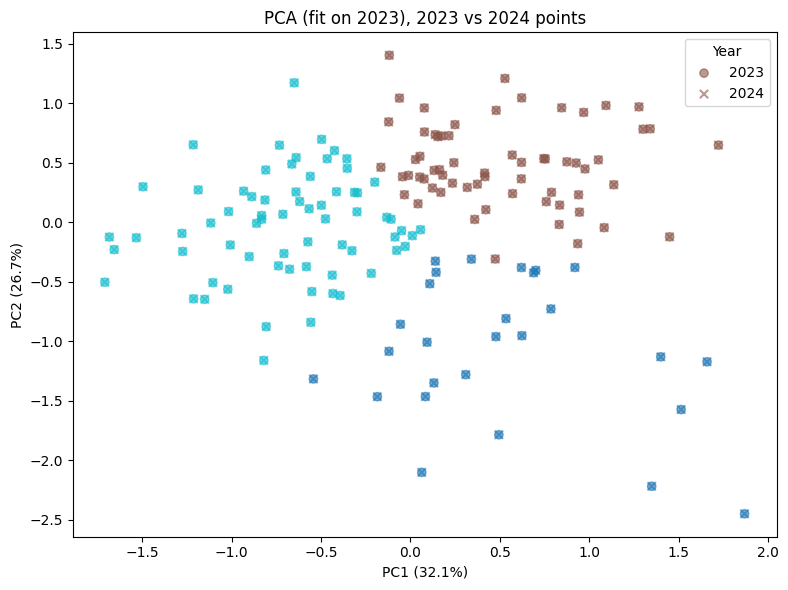

In [339]:
plt.figure(figsize=(8,6))
for y, m in [(2023, 'o'), (2024, 'x')]:
    subset = plot_both[plot_both['year']==y]
    plt.scatter(subset['PC1'], subset['PC2'],
                c=subset['cluster'], cmap='tab10', marker=m, alpha=0.6, label=str(y))
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.title("PCA (fit on 2023), 2023 vs 2024 points")
plt.legend(title="Year")
plt.tight_layout(); plt.show()


# Sanity Check

In [340]:
# should be True
wide_feats['HOOD_158'].nunique() == wide_feats.shape[0]

True

In [341]:
#No missing:
final_matrix.isna().sum()

,0
hood_158,0
assault_mean_rate_q1_2021,0
auto_theft_mean_rate_q1_2021,0
break_and_enter_mean_rate_q1_2021,0
robbery_mean_rate_q1_2021,0
...,...
crime_rate_per_1000,0
median_total_income_in_2020_among_recipients,0
average_household_size,0
of_owner_households_spending_30_or_more_of_its_income_on_shelter_costs,0


In [342]:
#One row per hood:
final_matrix["hood_158"].nunique(), final_matrix.shape[0]

(158, 158)

In [343]:
#Feature distributions:
# get summary stats
desc = final_matrix.drop('hood_158', axis=1).describe().T
desc[['mean', 'std', 'min', 'max']]



,mean,std,min,max
crime_rate_per_1000,2.823244e-01,0.143031,0.111265,1.031353
median_total_income_in_2020_among_recipients,-8.994212e-17,1.003180,-1.334009,3.192734
average_household_size,5.565169e-16,1.003180,-2.294083,3.208688
of_owner_households_spending_30_or_more_of_its_income_on_shelter_costs,-1.349132e-16,1.003180,-1.567201,3.361496
in_core_housing_need,-2.951226e-16,1.003180,-1.744261,2.827639


## Scale all numeric features to z‑scores

In [344]:
# === USE THE BALANCED MATRIX INSTEAD OF THE OLD ONE ===========================
id_col = 'hood_158'

ids          = X_balanced[[id_col]]
feature_df   = X_balanced.drop(columns=id_col)
numeric_cols = feature_df.columns  # everything here is numeric and already balanced

# No need to scale again – it's already scaled & block-weighted above.
X = feature_df.values  # numpy array for clustering libs that expect it

print(X.shape, "features:", len(numeric_cols))
# ============================================================================


(158, 98) features: 98


# Find the right k (Elbow + Silhouette)

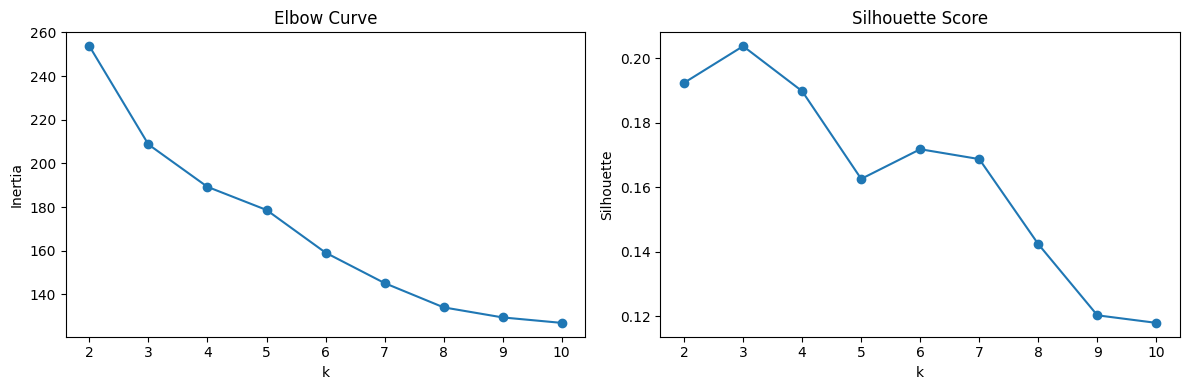

In [345]:
inertia_list, sil_list = [], []
K_range = range(2,11)

X_mat = X  # X was feature_df.values
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X_mat)
    inertia_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_mat, km.labels_))


fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,4))
ax1.plot(K_range, inertia_list,   'o-'); ax1.set_title('Elbow Curve');       ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax2.plot(K_range, sil_list,       'o-'); ax2.set_title('Silhouette Score'); ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

In [346]:


def silhouette_diagnostics(X, k):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X)
    labels = km.labels_
    sil_all = silhouette_samples(X, labels)
    print(f"k={k}  overall silhouette={sil_all.mean():.3f}")
    for c in np.unique(labels):
        print(f"  cluster {c}: n={np.sum(labels==c)}  mean_sil={sil_all[labels==c].mean():.3f}")
    return km, sil_all

km3, sil3 = silhouette_diagnostics(feature_df, 3)


k=3  overall silhouette=0.204
  cluster 0: n=26  mean_sil=0.041
  cluster 1: n=65  mean_sil=0.216
  cluster 2: n=67  mean_sil=0.255


In [347]:
# X_mat = feature_df.values   # already created earlier
best_k = 3
km = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
labels = km.fit_predict(X_mat)   # <-- no string indexing

X_balanced['cluster'] = labels
final_matrix = final_matrix.merge(
    X_balanced[[id_col, 'cluster']], on=id_col, how='left'
)


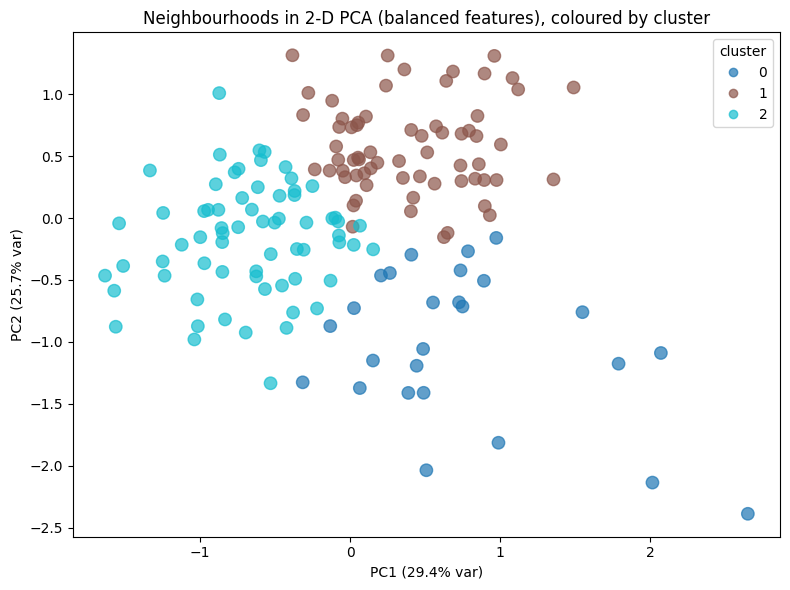

In [348]:

id_col = 'hood_158'

# 1) Use the balanced matrix you created earlier
#    (X_balanced has id_col + balanced features, and now also 'cluster')
plot_df = X_balanced.copy()

# 2) Keep only numeric feature columns (drop id and cluster)
feat_cols = [c for c in plot_df.columns if c not in [id_col, 'cluster']]
X_for_pca = plot_df[feat_cols].astype(float).values  # ensure numeric

# 3) Run PCA
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_for_pca)

# 4) Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X2[:,0], X2[:,1],
    c=plot_df['cluster'],
    cmap='tab10',
    alpha=0.7,
    s=80
)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
plt.title("Neighbourhoods in 2‑D PCA (balanced features), coloured by cluster")
plt.legend(*scatter.legend_elements(), title="cluster")
plt.tight_layout()
plt.show()


In [349]:
id_col = 'hood_158'

# Make sure cluster column exists where you think it does
print("'cluster' in X_balanced?", 'cluster' in X_balanced.columns)
print("'cluster' in final_matrix?", 'cluster' in final_matrix.columns)

# If final_matrix is missing the labels, merge them in:
if 'cluster' not in final_matrix.columns:
    final_matrix = final_matrix.merge(
        X_balanced[[id_col, 'cluster']], on=id_col, how='left'
    )


'cluster' in X_balanced? True
'cluster' in final_matrix? True


In [350]:
# Use the balanced DataFrame
base_df   = X_balanced.copy()
feat_cols = [c for c in base_df.columns if c not in [id_col, 'cluster']]

# Centroids (mean per cluster)
centroids = base_df.groupby('cluster')[feat_cols].mean()

# Effect sizes: how far each cluster is from overall mean (in SD units)
overall_mean = base_df[feat_cols].mean()
overall_std  = base_df[feat_cols].std(ddof=0)  # ddof=0 to avoid tiny divisions
effect_sizes = (centroids - overall_mean) / overall_std

display(centroids.head())      # raw means (already standardized+weighted, but OK)
display(effect_sizes.head())   # interpretable deviations


,socio__median_total_income_in_2020_among_recipients,socio__average_household_size,socio__of_owner_households_spending_30_or_more_of_its_income_on_shelter_costs,socio__in_core_housing_need,crime__assault_mean_rate_q1_2021,crime__auto_theft_mean_rate_q1_2021,crime__break_and_enter_mean_rate_q1_2021,crime__robbery_mean_rate_q1_2021,crime__theft_over_mean_rate_q1_2021,crime__assault_mean_rate_q2_2021,...,crime__theft_over_cv_counts,crime__assault_yearly_amp,crime__assault_yearly_peak_month,crime__assault_half_amp,crime__assault_half_peak_month,crime__assault_median_total_income_in_2020_among_recipients,crime__assault_average_household_size,crime__assault_of_owner_households_spending_30_or_more_of_its_income_on_shelter_costs,crime__assault_in_core_housing_need,crime__crime_rate_per_1000
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.224673,-0.746756,0.534257,0.108213,0.128792,-0.060225,0.097938,0.066352,0.068326,0.123651,...,-0.087942,0.111986,0.013999,0.031667,0.054690,0.046346,-0.154044,0.110209,0.022323,0.109508
1,-0.387680,0.321591,0.195264,0.384094,-0.011408,0.026032,-0.034233,-0.008173,-0.005402,-0.010838,...,-0.012107,-0.029188,-0.013724,-0.005973,-0.017446,-0.079972,0.066339,0.040280,0.079233,-0.012552
2,0.288921,-0.022205,-0.396759,-0.414622,-0.038912,-0.001884,-0.004794,-0.017819,-0.021274,-0.037470,...,0.045872,-0.015140,0.007882,-0.006495,-0.004298,0.059600,-0.004581,-0.081845,-0.085530,-0.030318


,socio__median_total_income_in_2020_among_recipients,socio__average_household_size,socio__of_owner_households_spending_30_or_more_of_its_income_on_shelter_costs,socio__in_core_housing_need,crime__assault_mean_rate_q1_2021,crime__auto_theft_mean_rate_q1_2021,crime__break_and_enter_mean_rate_q1_2021,crime__robbery_mean_rate_q1_2021,crime__theft_over_mean_rate_q1_2021,crime__assault_mean_rate_q2_2021,...,crime__theft_over_cv_counts,crime__assault_yearly_amp,crime__assault_yearly_peak_month,crime__assault_half_amp,crime__assault_half_peak_month,crime__assault_median_total_income_in_2020_among_recipients,crime__assault_average_household_size,crime__assault_of_owner_households_spending_30_or_more_of_its_income_on_shelter_costs,crime__assault_in_core_housing_need,crime__crime_rate_per_1000
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.449345,-1.493513,1.068515,0.216427,1.248681,-0.583902,0.949540,0.643310,0.662448,1.198838,...,-0.852631,1.085748,0.135728,0.307028,0.530239,0.449345,-1.493513,1.068515,0.216427,1.061721
1,-0.775361,0.643182,0.390528,0.768189,-0.110603,0.252390,-0.331905,-0.079245,-0.052370,-0.105076,...,-0.117380,-0.282993,-0.133059,-0.057906,-0.169145,-0.775361,0.643182,0.390528,0.768189,-0.121700
2,0.577843,-0.044410,-0.793518,-0.829244,-0.377261,-0.018267,-0.046481,-0.172763,-0.206263,-0.363282,...,0.444748,-0.146790,0.076417,-0.062968,-0.041668,0.577843,-0.044410,-0.793518,-0.829244,-0.293944


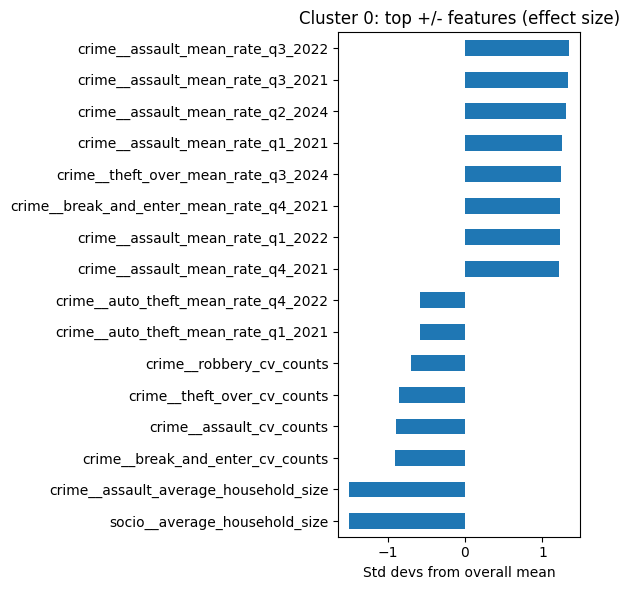

/tmp/ipython-input-351-3841100040.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


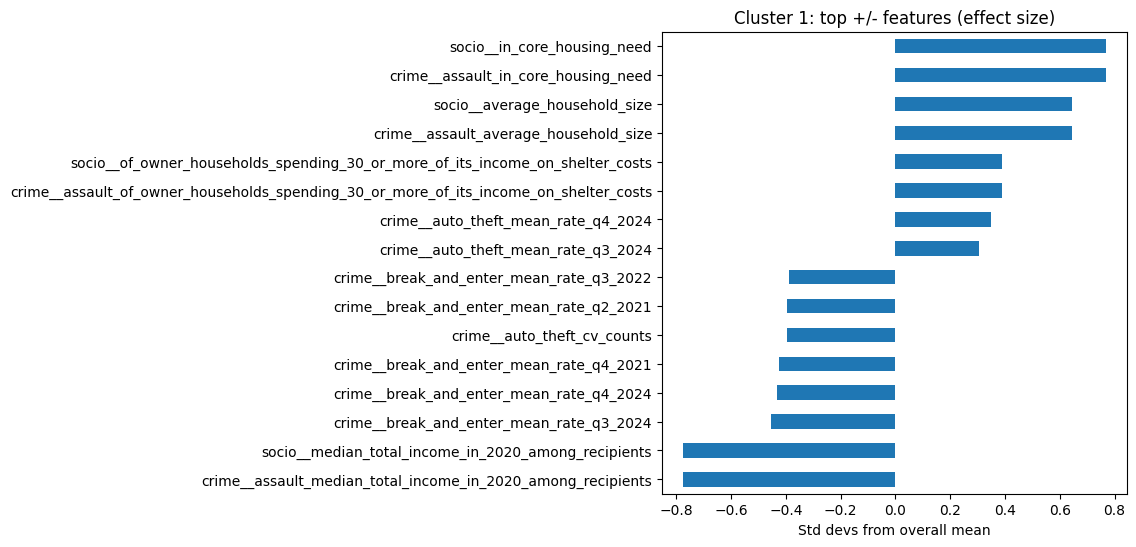

/tmp/ipython-input-351-3841100040.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


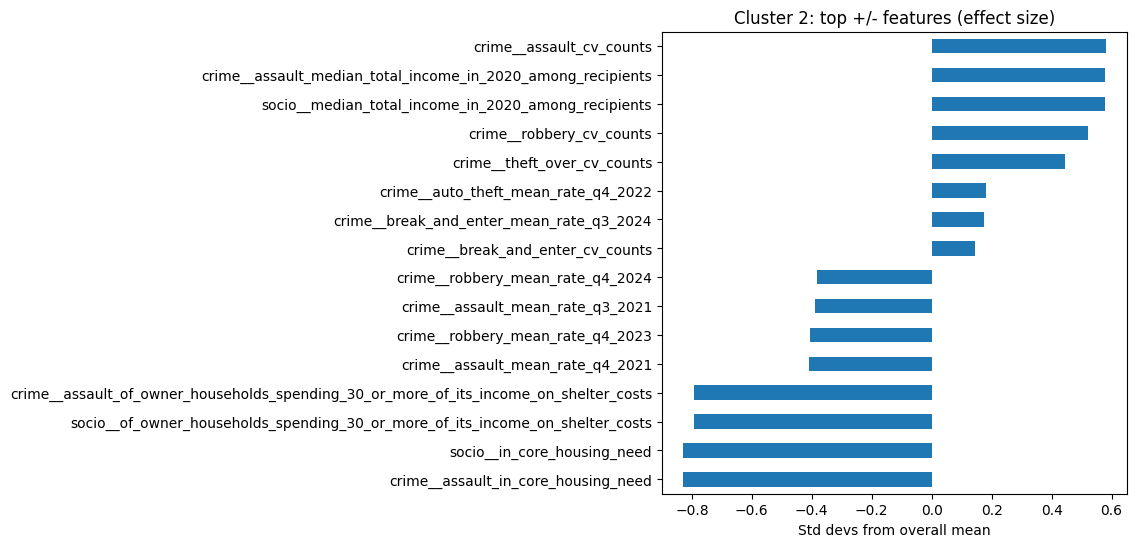

In [351]:
import pandas as pd
import matplotlib.pyplot as plt

def top_n_effects(eff_df, cluster_id, n=10):
    s = eff_df.loc[cluster_id].sort_values()
    return pd.concat([s.head(n), s.tail(n)])

for c in effect_sizes.index:
    top_feats = top_n_effects(effect_sizes, c, n=8)
    ax = top_feats.plot(kind='barh', figsize=(6,6))
    ax.set_title(f"Cluster {c}: top +/- features (effect size)")
    ax.set_xlabel("Std devs from overall mean")
    plt.tight_layout()
    plt.show()


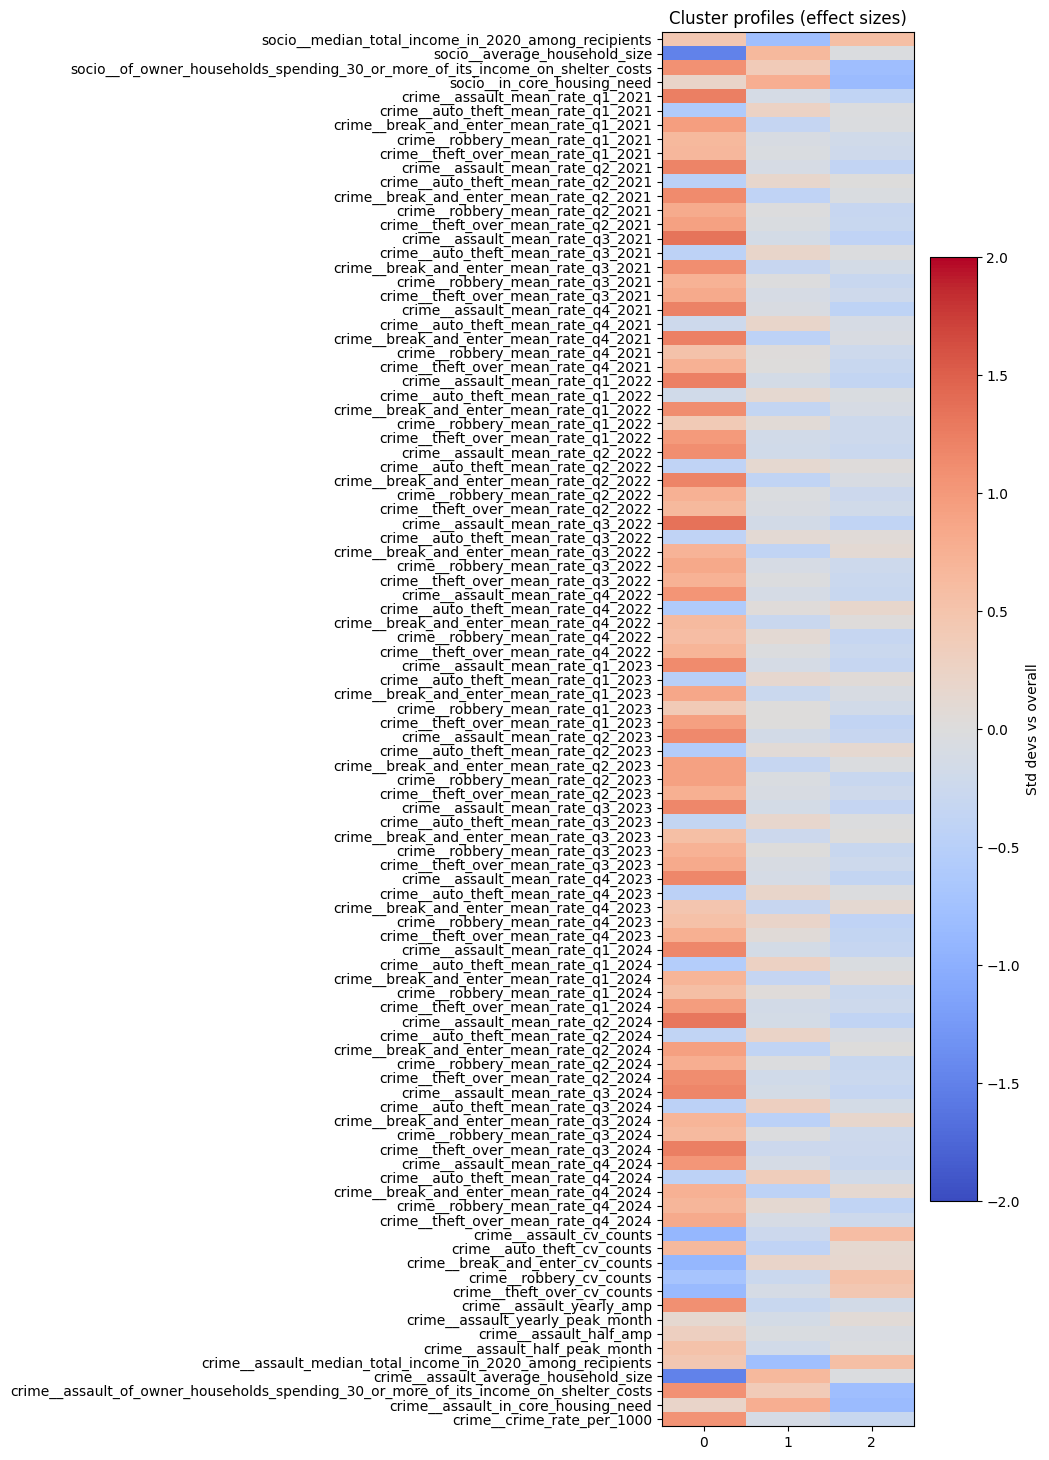

In [352]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, max(6, len(feat_cols)*0.15)))
im = ax.imshow(effect_sizes.T, aspect='auto', cmap='coolwarm', vmin=-2, vmax=2)
ax.set_yticks(range(len(feat_cols)))
ax.set_yticklabels(feat_cols)
ax.set_xticks(range(len(effect_sizes.index)))
ax.set_xticklabels(effect_sizes.index)
plt.colorbar(im, ax=ax, label='Std devs vs overall')
ax.set_title("Cluster profiles (effect sizes)")
plt.tight_layout()
plt.show()


# HDBSCAN Clustering

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN labels: {np.int64(0): np.int64(69), np.int64(1): np.int64(48), np.int64(2): np.int64(41)}


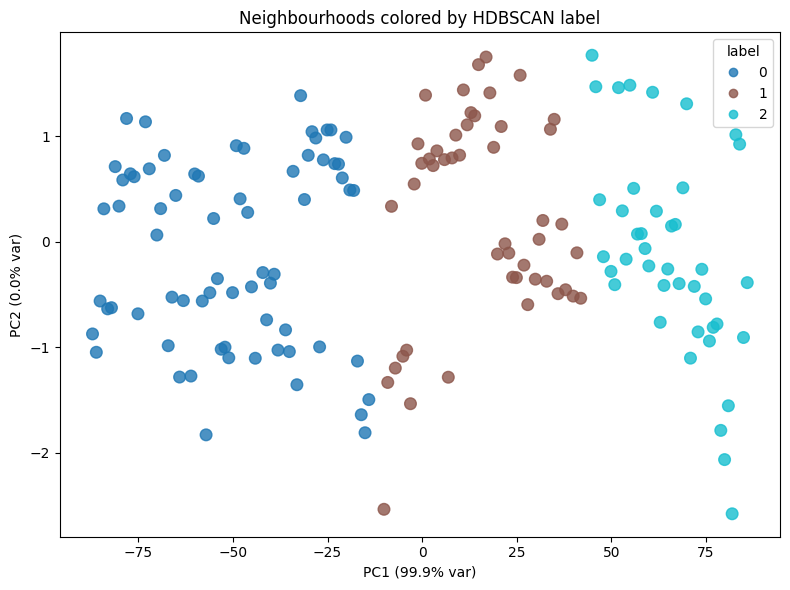

In [353]:
# 1) Fit HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=2,
    metric='euclidean',
    cluster_selection_method='eom'
)
labels = clusterer.fit_predict(X_balanced)

# 2) Inspect how many clusters (–1 = noise)
unique, counts = np.unique(labels, return_counts=True)
print("HDBSCAN labels:", dict(zip(unique, counts)))

# 3) Attach labels to your neighbourhood table
final_matrix = final_matrix.copy()
final_matrix["hdbscan_label"] = labels

# 4) Quick 2‑D visualization via PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_balanced)
var1, var2 = pca.explained_variance_ratio_[:2]

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=labels,
    cmap='tab10',
    s=70, alpha=0.8
)
plt.title("Neighbourhoods colored by HDBSCAN label")
plt.xlabel(f"PC1 ({var1:.1%} var)")
plt.ylabel(f"PC2 ({var2:.1%} var)")
plt.legend(*sc.legend_elements(), title="label", loc='best')
plt.tight_layout()
plt.show()

In [354]:
# Keep for reuse everywhere
id_col    = 'hood_158'
feat_cols = [c for c in X_balanced.columns if c not in [id_col, 'cluster']]
